<b><font size="6"> Data Mining Project - Group 40 2025/2026 </font></b><br><br>
<i> <font size="4"> Amazing International Airlines Inc. (AIAI)</font></i>

`Group 40`

20250380 Maria Fonseca <br>
20250405 Ana Macedo <br>
20250453 Lourenço Silva <br>

### <font color='#0357acff'>**Methodology** </font> <a class="anchor" id='TOP'></a> 


- [1. Import libraries](#1) 
- [2. Loading the Data](#2) 
- [3. Metadata](#3)
- [4. Business Understanding](#4)
- [5. Data Preprocessing](#6)
    - [5.1. Duplicates](#6_1)
    - [5.2. Inconsistencies](#6_2)
    - [5.3. Missing Values](#6_3)
    - [5.4. Outliers](#6_4)
    - [5.5. Feature Engineering FlightsDB](#5_5)
    






<a class="anchor" id="1">

# **1. Import libraries**

[Back to TOP](#TOP)
</a>

In [2]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from matplotlib.pylab import log1p
from matplotlib import colors as mpl_colors
from matplotlib import cm, colorbar
from matplotlib.colors import LinearSegmentedColormap

from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.cluster import DBSCAN, HDBSCAN, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, r2_score

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

# Import the functions that were created
from functions import *

from IPython.display import Markdown

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

np.random.seed(40311)
sns.set()

#self organizing maps
from minisom import MiniSom


import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from matplotlib.pylab import log1p
from matplotlib import cm, colorbar
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib.patches import RegularPolygon
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.cluster import DBSCAN, HDBSCAN, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, r2_score

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# Self-Organizing Maps
from minisom import MiniSom

# Import the functions that were created
from functions import *

from IPython.display import Markdown

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

np.random.seed(40311)
sns.set()

<a class="anchor" id="2">

# **2. Loading the Data**

[Back to TOP](#TOP)
</a>

In [3]:
flightsDB_original = pd.read_csv('../../data/DM_AIAI_FlightsDB.csv', sep = ",")
customerDB_original = pd.read_csv('../../data/DM_AIAI_CustomerDB.csv', sep = ",")
metaData = pd.read_csv('../../data/DM_AIAI_Metadata.csv', sep = ";", header= None)

Remove the 'Unnamed' column referring to a sequential numbering of the rows, as we set the column "Loyalty#" as the index

In [4]:
customerDB_original = customerDB_original.iloc[:, 1:]
customerDB_original

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


In [5]:
flightsDB = flightsDB_original.copy()
customerDB = customerDB_original.copy()

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#TOP)
</a>

**FlightsDB Database feature Description**
- **Loyalty#:**	Unique customer identifier linking to CustomerDB
- **Year:**	Year of flight activity record
- **Month:**	Month of flight activity record (1-12)
- **YearMonthDate:**	First day of the month for the activity period
- **NumFlights:**	Total number of flights taken by customer in the month
- **NumFlightsWithCompanions:**	Number of flights where customer traveled with companions
- **DistanceKM:**	Total distance traveled in kilometers for the month
- **PointsAccumulated:**	Loyalty points earned by customer during the month
- **PointsRedeemed:**	Loyalty points spent/redeemed by customer during the month
- **DollarCostPointsRedeemed:**	Dollar value of points redeemed during the month

**CustomerDB Database feature Description**
- **Loyalty#:**  Unique customer identifier for loyalty program members
- **First Name:**   Customer's first name
- **Last Name:**   Customer's last name 
- **Customer Name:** Customer's full name (concatenated)
- **Country:**	Customer's country of residence
- **Province or State:**	Customer's province or state
- **City:**	Customer's city of residence
- **Latitude:**	Geographic latitude coordinate of customer location
- **Longitude:**	Geographic longitude coordinate of customer locatio
- **Postal code:**	Customer's postal/ZIP code
- **Gender:**	Customer's gender
- **Education:**	Customer's highest education level (Bachelor, College, etc.)
- **Location:** Code	Urban/Suburban/Rural classification of customer residence
- **Income:**	Customer's annual income
- **Marital Status:**	Customer's marital status (Married, Single, Divorced)
- **LoyaltyStatus:**	Current tier status in loyalty program (Star > Nova > Aurora)
- **EnrollmentDateOpening:**	Date when customer joined the loyalty program
- **CancellationDate:**	Date when customer left the program
- **Customer Lifetime:** Value	Total calculated monetary value of customer relationship
- **EnrollmentType:**	Method of joining loyalty program

<a class="anchor" id="4">

# **4. Business Understanding**

[Back to TOP](#TOP)
</a>

Amazing International Airlines Inc. (AIAI) operates in a highly competitive industry, where customer retention and loyalty are essential for profitability. 

The company has a loyalty program but lacks personalization and individualized engagement strategies, limiting its ability to achieve high levels of customer satisfaction. As a result, marketing campaigns and rewards are often generic, reducing the effectiveness of loyalty initiatives. 

The company’s main challenge is to reduce customer churn and optimize the performance of its loyalty program. Without detailed insights into the different customer profiles, it becomes difficult to offer personalized services and targeted offers that enhance satisfaction and engagement. 

The main goal is to implement a data-driven approach to segment AIAI’s customers, identifying distinct groups based on behavioral, demographic, and value-related factors. This segmentation will allow the company to create personalized marketing strategies, develop targeted loyalty offers, and ultimately reduce customer churn by 5%, which corresponds to approximately €50,000 in monthly savings. To support these business goals, the project will aim to develop a clustering model capable of distinguishing customer profiles, create customer segments and ensure the model is scalable and adaptable to evolving customer behavior.

 The project will follow five main stages, aligned with the CRISP-DM methodology. 
 It will begin with an exploratory data analysis (EDA) to understand the available data, assess its quality, and identify potential issues such as missing values or outliers. 
 The second stage will involve data preprocessing, including cleaning, normalization, and transformation to prepare the dataset for clustering. 
 Next, clustering techniques will be applied to identify distinct customer groups based on behavioral, demographic, and value-related factors. 
 The fourth stage will focus on evaluating the model’s performance and interpreting the resulting segments to extract actionable marketing insights. Finally, the model will be deployed and continuously monitored to ensure scalability and adaptability as customer behavior evolves.

<a class="anchor" id="5">

# **5. Data Preprocessing**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_1">

## **5.1.** Duplicates

[Back to TOP](#TOP)
</a>

In [6]:
flightsDB[flightsDB.duplicated(keep=False)]
#This code will display the duplicated rows in the flight dataset which are 5778 rows in Total

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
450,727091,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
535,369638,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
762,750578,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
941,547522,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
952,819842,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
607696,960050,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608110,981508,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608111,981508,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608263,990512,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
customerDB[customerDB.duplicated(keep=False)]
#This code will display the duplicated rows in the customer dataset which are 0 rows in Total

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType


In [8]:
flightsDB.drop_duplicates(inplace=True)
customerDB.drop_duplicates(inplace=True)

In [9]:
flightsDB.set_index('Loyalty#', inplace=True)
customerDB.set_index('Loyalty#', inplace=True)

<a class="anchor" id="5_2">

## **5.2.** Inconsistencies

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_2_1">

### 5.2.1. Number of Flights as floats

[Back to TOP](#TOP)
</a>

In [10]:
flightsDB["NumFlights"] = flightsDB["NumFlights"].astype(int)
flightsDB["NumFlightsWithCompanions"] = flightsDB["NumFlightsWithCompanions"].astype(int)

In [11]:
# Check inconsistency between Points Accumulated and Points Redeemed
total_accumulated = flightsDB.groupby('Loyalty#')['PointsAccumulated'].sum()
total_redeemed = flightsDB.groupby('Loyalty#')['PointsRedeemed'].sum()

#inconsitency in 458 observations
(total_redeemed > total_accumulated).sum()

np.int64(458)

The consistency check identified 458 customers who redeemed more points than they accumulated.
Since the business rules of the loyalty program are not fully known (e.g., bonuses, promotions, or historical points not captured in the data), these cases were kept in the dataset to avoid introducing bias or making unsupported assumptions.

<a class="anchor" id="5_2_1">

### 5.2.1. CancellationDate and EnrollmentDateOpening formatting

[Back to TOP](#TOP)
</a>

Here we will change the format of the feature that represent dates so we can make computations with them.

In [12]:
flightsDB['YearMonthDate'] = pd.to_datetime(
    flightsDB['YearMonthDate'], errors='coerce')

customerDB['CancellationDate'] = pd.to_datetime(
    customerDB['CancellationDate'], errors='coerce')

customerDB['EnrollmentDateOpening'] = pd.to_datetime(
    customerDB['EnrollmentDateOpening'], errors='coerce')

<a class="anchor" id="5_3">

## **5.3.** Missing Values

[Back to TOP](#TOP)
</a>

In [13]:
print(f" \033[1mThe total number of missing values in flightsDB and customerDB is:\033[0m \
      {(flightsDB.isna().sum().sum(), customerDB.isna().sum().sum())}")

 The total number of missing values in flightsDB and customerDB is:       (np.int64(0), np.int64(14653))


In [14]:
print(" \033[1mFor the customerDB we have the following missing values per column:\033[0m")
print("\n")
print(customerDB.isna().sum())
print("\n")
percentage_missing_C = (customerDB.isna().sum().sum() / len(customerDB)) * 100
percentage_missing_total = ((flightsDB.isna().sum().sum() + customerDB.isna().sum().sum()) / (len(flightsDB) + len(customerDB))) * 100
print(f"\033[1mThe total percentage of missing values in customerDB is:\033[0m {percentage_missing_C:.2f}%")
print(f"\033[1mThe total percentage of missing values in both datasets is:\033[0m {percentage_missing_total:.2f}%")

 For the customerDB we have the following missing values per column:


First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64


The total percentage of missing values in customerDB is: 86.60%
The total percentage of missing values in both datasets is: 2.35%


In [15]:
# fill missing values in Income with median
median_income = customerDB["Income"].median()
customerDB["Income"] = customerDB["Income"].fillna(median_income)

# fill missing values in CancellationDate with "31-12-2021" that is the end date of the data collection period and means the customer is still active
customerDB["CancellationDate"] = customerDB["CancellationDate"].fillna("31-12-2021")

# fill missing values in CLV with median
median_clv =customerDB["Customer Lifetime Value"].median()
customerDB['Customer Lifetime Value'] = customerDB["Customer Lifetime Value"].fillna(median_clv)

<a class="anchor" id="5_4">

## **5.4.** Univariate Outliers Treatment

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_4_1">

### 5.4.1. Outliers Flights Dataset

[Back to TOP](#TOP)
</a>

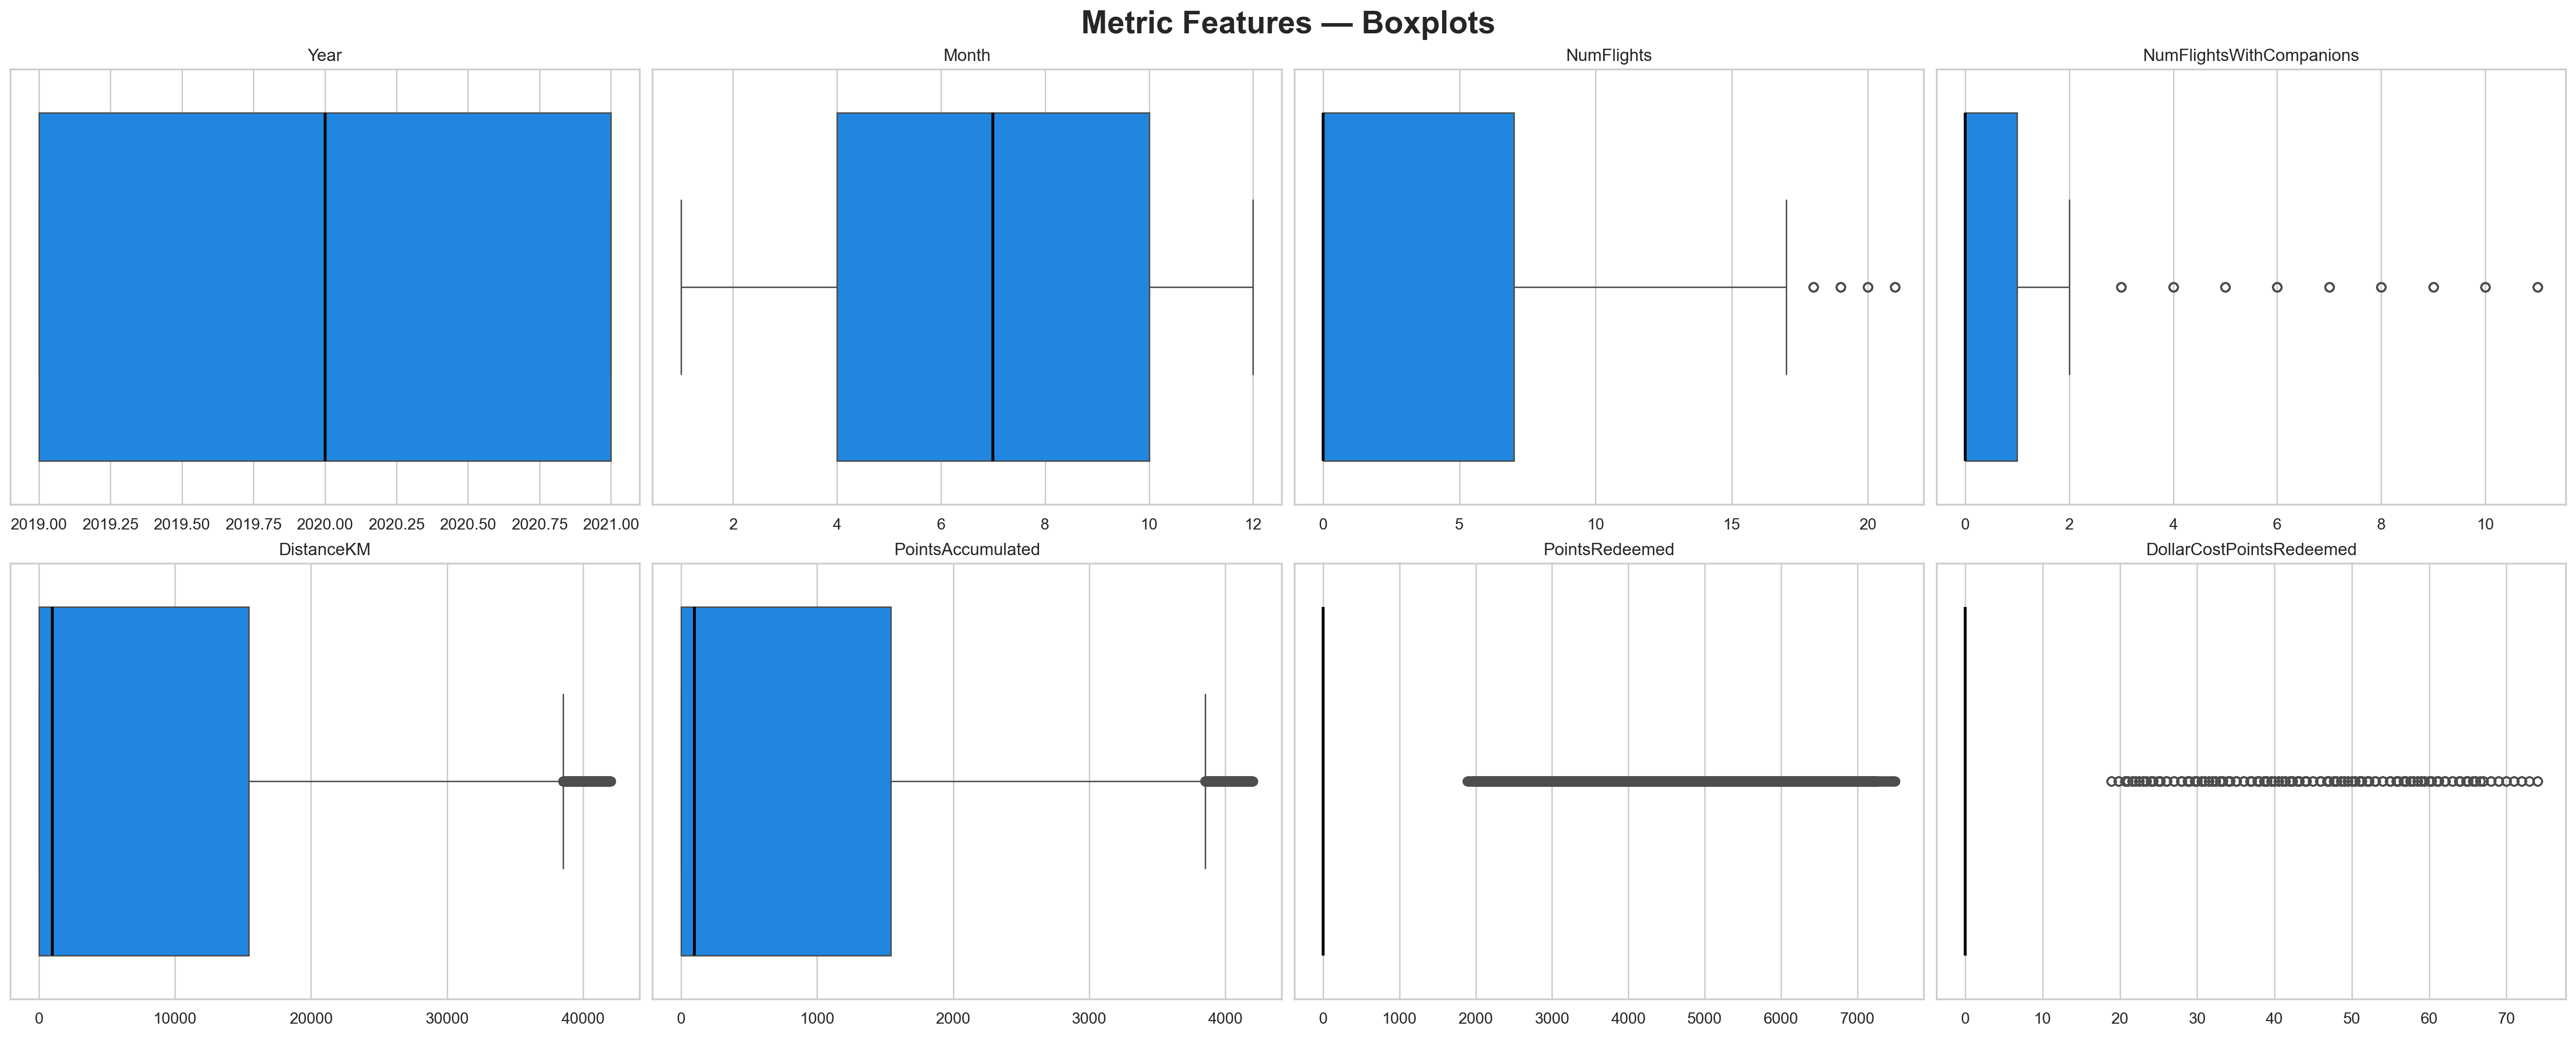

In [16]:
create_boxplots(flightsDB, n_cols=4, figsize=(25, 10))

Treat the outliers by removing a small percentage of the highest values, defining a threshold for extreme observations. This decision is based on the fact that all outliers appear on the right side of the boxplots, indicating that the data is heavily left skewed.

In [17]:
columns_to_cap = ['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed' ]

flightsDB_clean = treat_outliers_cap(flightsDB, columns_to_cap, threshold=0.999)

In [18]:
print('Percentage of data kept after removing outliers:', np.round(flightsDB_clean.shape[0] / flightsDB.shape[0], 4) * 100, '%')

Percentage of data kept after removing outliers: 99.44 %


<a class="anchor" id="5_4_2">

### 5.4.2. Outliers Customer Dataset

[Back to TOP](#TOP)
</a>

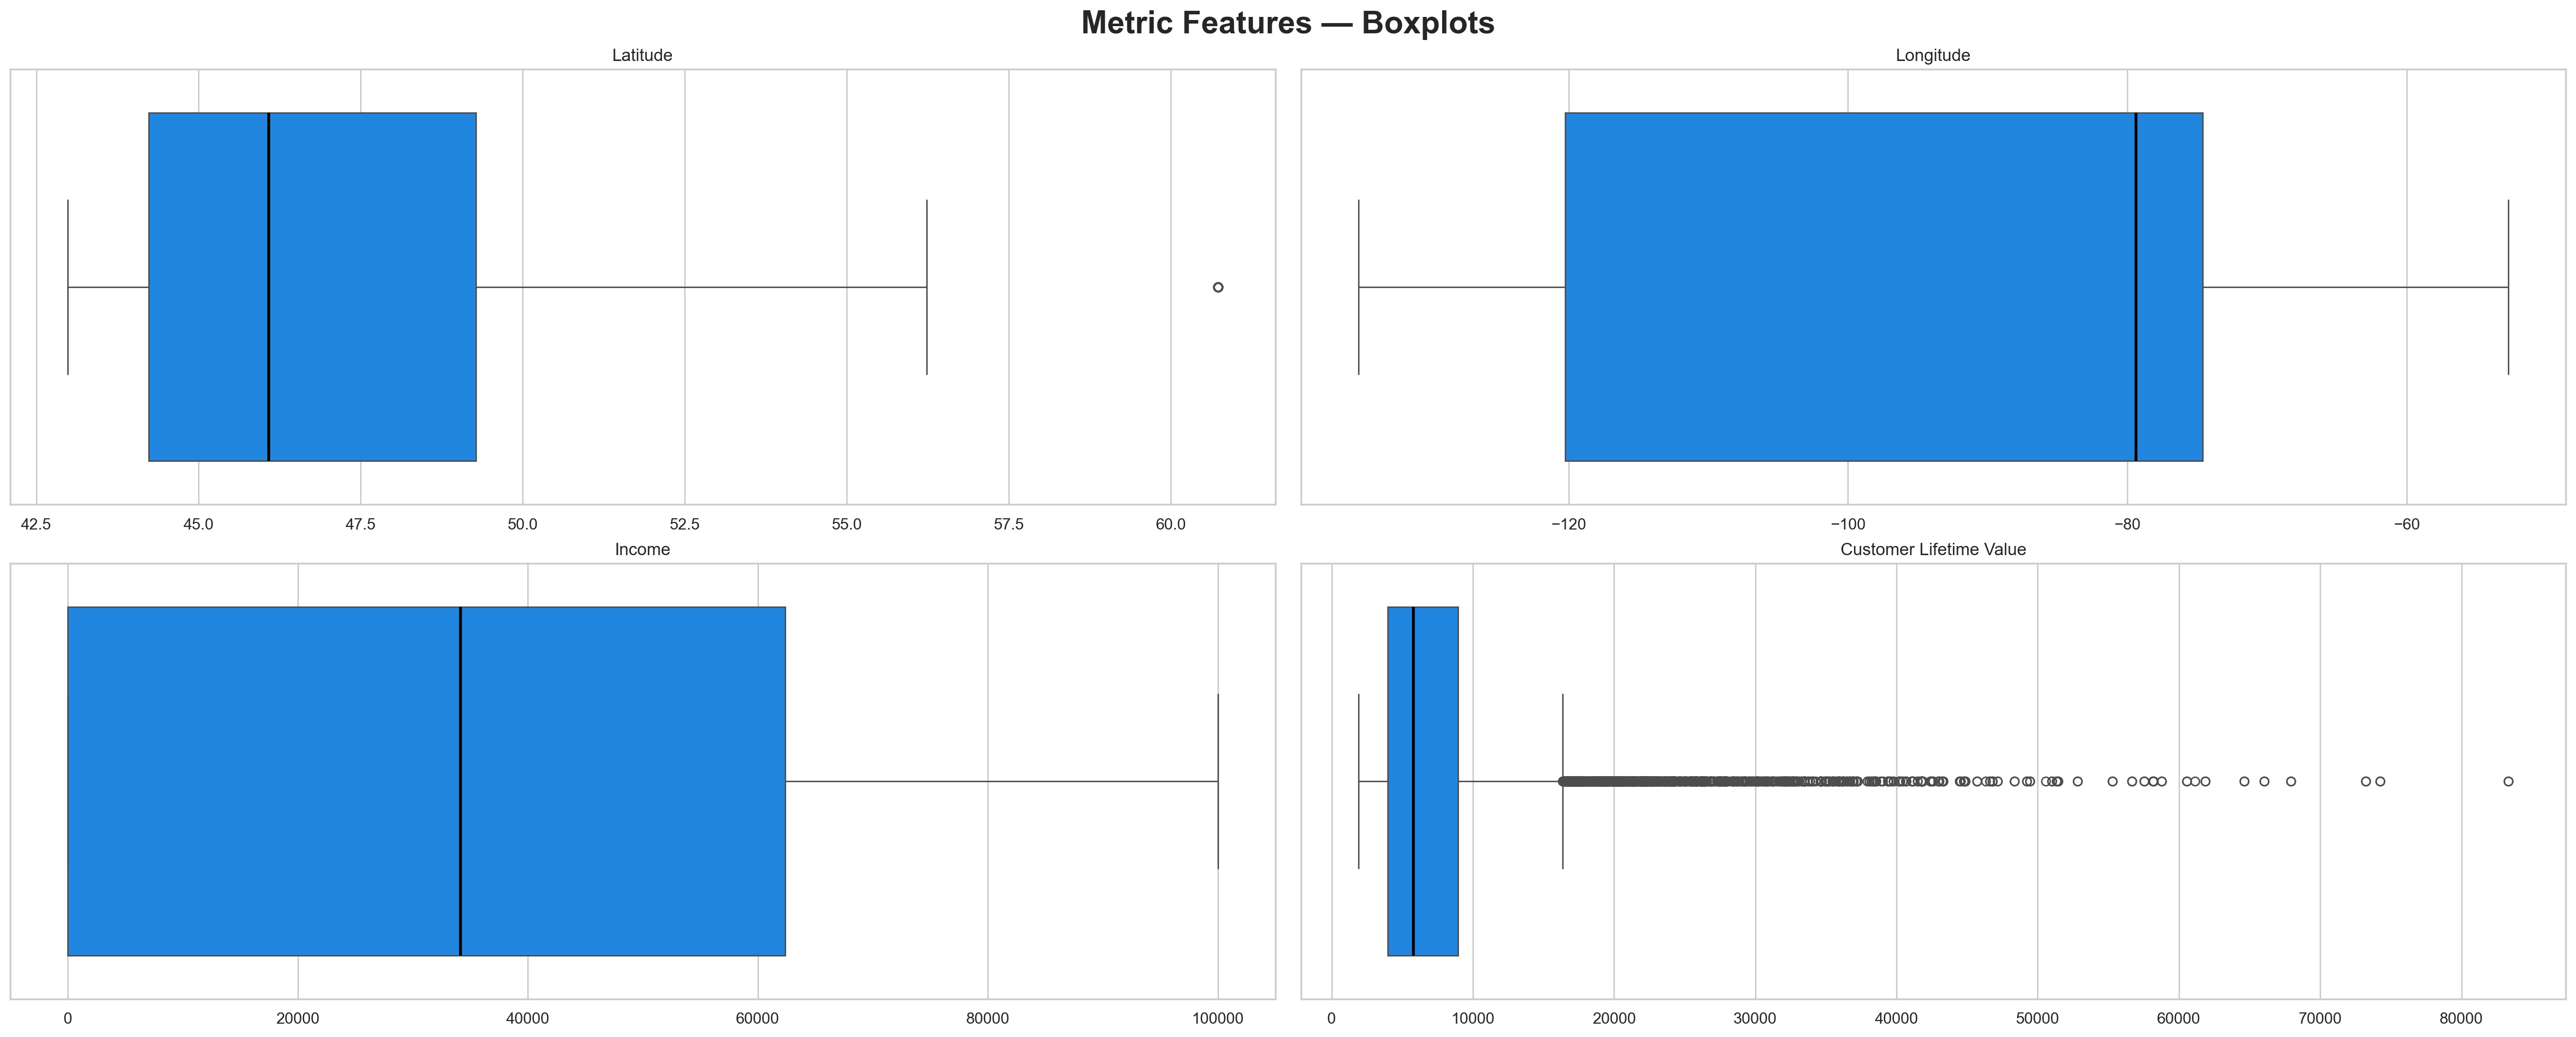

In [19]:
create_boxplots(customerDB, n_cols=2, figsize=(25, 10))

In [20]:
customerDB_clean = treat_outliers_cap(customerDB, ['Customer Lifetime Value'], threshold=0.999)

In [21]:
print('Percentage of data kept after removing outliers:', np.round(customerDB_clean.shape[0] / customerDB.shape[0], 4) * 100, '%')

Percentage of data kept after removing outliers: 99.9 %


In [22]:
print('Percentage of total data kept after removing outliers:' , np.round((flightsDB_clean.shape[0] + customerDB_clean.shape[0]) / (flightsDB_original.shape[0] + customerDB_original.shape[0]) * 100, 2), '%')

Percentage of total data kept after removing outliers: 98.99 %


In [23]:
flightsDB = flightsDB_clean.copy()
customerDB = customerDB_clean.copy()

<a class="anchor" id="5_5">

## **5.5.** Feature Engineering - FlightsDB

[Back to TOP](#TOP)
</a>

Given that our project involves two datasets from the airline company—the flights dataset includes multiple records per customer reflecting their activity over time and the customer dataset only contains a single row per customer, we must ensure that the final dataset used for clustering is structured appropriately.

Clustering algorithms require each observation to represent a single entity; therefore, the final dataset must contain exactly one row per customer (one per Loyalty#), matching the structure of the customer dataset.

To achieve this, we will aggregate variables of the flights datset to create new features that summarize each customer's overall behavior. These aggregated features will then be merged with the customer dataset, ensuring that each customer is represented by a single, information, rich record suitable for clustering. 
This approach allows us to retain important behavioral patterns that would otherwise be lost.

In addition to the aggregated features derived from the flights dataset, we will also engineer new features directly from the customer dataset.
Overall, this feature engineering step is essential for integrating both datasets into a single, clean, and informative dataset for clustering.

<a class="anchor" id="5_5_1">

### 5.5.1. Summary Features
[Back to TOP](#TOP)
</a>

`Total_Flights:` Total number of flights taken by each customer 

`Total_Flights_With_Companions:` Total number of flights taken with companions by each customer

`Total_DistanceKM:` Total distance traveled in kilometers by each customer

`Total_Points_Accumulated:` Total loyalty points accumulated by each customer

`Total_Points_Redeemed:` Total loyalty points redeemed by each customer

`Flights_Variance:` Variance in the number of flights taken by each customer

In [24]:
# CREATE SUMMARY FEATURES FOR FLIGHTSDB
# Aggregate by customer and rename in one step
flightsDB_fe = (
    flightsDB.groupby('Loyalty#', as_index=True)  # keep Loyalty# as index
    .agg(
        Total_Flights=('NumFlights', 'sum'),
        Total_Flights_With_Companions=('NumFlightsWithCompanions', 'sum'),
        Total_DistanceKM=('DistanceKM', 'sum'),
        Total_Points_Accumulated=('PointsAccumulated', 'sum'),
        Total_Points_Redeemed=('PointsRedeemed', 'sum'),
        Flights_Variance=('NumFlights', 'var'),
    )
)

<a class="anchor" id="5_5_2">

### 5.5.2. Travelers Type
[Back to TOP](#TOP)
</a>

`Did_Travel:` Indicator of whether the customer traveled or not

`Solo_travels:` Number of solo travels by each customer

`Only_Travel_With_Companions:` Indicator if the customer only traveled with companions (binary feature)

In [25]:
#We create a new binary column indicating if the customer traveled or not
flightsDB_fe['Did_Travel'] = np.where(flightsDB_fe['Total_Flights'] > 0, 1, 0)

# Create solo_travels feature that counts the number of flights without companions
flightsDB_fe['Solo_Travels'] = np.where(
    flightsDB_fe['Did_Travel'] == 1,
    flightsDB_fe['Total_Flights'] - flightsDB_fe['Total_Flights_With_Companions'],
    0
)

# Create OnlyTraveledWithCompanions feature
flightsDB_fe['Only_Travel_With_Companions'] = (
    (flightsDB_fe['Total_Flights'] > 0) &
    (flightsDB_fe['Solo_Travels'] == 0)
).astype(int)

<a class="anchor" id="5_5_3">

### 5.5.3. Ratio Features
[Back to TOP](#TOP)
</a>

`Total_Flights_With_Companions_Ratio:`  Ratio of flights taken with companions to total flights for each customer.

In [26]:
# Flights With Companions Ratio
# Avoid division by zero
flightsDB_fe['Total_Flights_With_Companions_Ratio'] = np.where(
    flightsDB_fe['Total_Flights'] > 0,
    flightsDB_fe['Total_Flights_With_Companions'] / flightsDB_fe['Total_Flights'],
    0
)

<a class="anchor" id="5_5_4">

### 5.5.4. Recency
[Back to TOP](#TOP)
</a>

`Recency:`  Number of months since the customer’s most recent flight, calculated up to December 2021. Customers with no recorded flights are assigned a high recency value.

`Recency_Normalized:`  Normalized recency measure that captures how recent a customer’s last flight is relative to the population, where higher values indicate more recent activity.


In [27]:
last_flight_date = (flightsDB[flightsDB['NumFlights'] != 0]
                    .groupby('Loyalty#')['YearMonthDate']
                    .max())
last_year = 2021
last_month = 12

recency = (last_year - last_flight_date.dt.year) * 12 + (last_month - last_flight_date.dt.month)

# Assign recency to flightsDB_fe, filling NaN with 100. This NaN represents customers with no flights
flightsDB_fe['Recency'] = recency.reindex(flightsDB_fe.index).fillna(100)

<a class="anchor" id="5_5_5">

### 5.5.5. Distance Per Flight
[Back to TOP](#TOP)
</a>

`Distance_Per_Flight:` Average distance traveled per flight by each customer

In [28]:
# Total Distance per Flight
# Avoid division by zero
flightsDB_fe['Distance_Per_Flight'] = np.where(
    flightsDB_fe['Total_Flights'] > 0,
    flightsDB_fe['Total_DistanceKM'] / flightsDB_fe['Total_Flights'],
    0
)

<a class="anchor" id="5_5_7">

### 5.5.7. Seasonal Features
[Back to TOP](#TOP)
</a>

`Winter_Flights:` Number of flights taken in winter

`Spring_Flights:` Number of flights taken in spring

`Summer_Flights:` Number of flights taken in summer

`Autumn_Flights:` Number of flights taken in autumn

`PreferredSeason:` Season with the highest number of flights for each customer

In [29]:
# Seasonal Number of Flights
flightsDB_fe['Winter_Flights'] = flightsDB[flightsDB['Month'].isin([12, 1, 2])].groupby('Loyalty#')['NumFlights'].sum()
flightsDB_fe['Spring_Flights'] = flightsDB[flightsDB['Month'].isin([3, 4, 5])].groupby('Loyalty#')['NumFlights'].sum()
flightsDB_fe['Summer_Flights'] = flightsDB[flightsDB['Month'].isin([6, 7, 8])].groupby('Loyalty#')['NumFlights'].sum()
flightsDB_fe['Autumn_Flights'] = flightsDB[flightsDB['Month'].isin([9, 10, 11])].groupby('Loyalty#')['NumFlights'].sum()

# Preferred Season
flightsDB_fe['Preferred_Season'] = flightsDB_fe[['Winter_Flights', 'Spring_Flights', 'Summer_Flights', 'Autumn_Flights']].idxmax(axis=1)

`Winter_Flights_Ratio:` Ratio of flights taken during the winter season to the total number of flights for each customer.

`Spring_Flights_Ratio:`  Ratio of flights taken during the spring season to the total number of flights for each customer.

`Summer_Flights_Ratio:`  Ratio of flights taken during the summer season to the total number of flights for each customer.

`Autumn_Flights_Ratio:`  Ratio of flights taken during the autumn season to the total number of flights for each customer.


In [30]:
# Seasonal Flight Ratios
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']

for season in seasons:
    flightsDB_fe[f'{season}_Flights_Ratio'] = np.where(
        flightsDB_fe['Total_Flights'] > 0,
        flightsDB_fe[f'{season}_Flights'] / flightsDB_fe['Total_Flights'],
        0
    )

<a class="anchor" id="5_6">

## **5.6.** Feature Engineering CustomerDB

[Back to TOP](#TOP)
</a>

In [31]:
# Create empty dataframe for customerDB new features with the same index as customerDB
customerDB_fe = pd.DataFrame(index=customerDB.index)

<a class="anchor" id="5_6_1">

### 5.6.1. Log Costumer Lifetime Value
[Back to TOP](#TOP)
</a>

`log_CLV:` Log-transformed Customer Lifetime Value

`relation_inc_clv:` Relation feature between CLV and Income

In [32]:
# Create new feature with log transformation of CLV
customerDB_fe["log_CLV"] = np.log1p(customerDB["Customer Lifetime Value"]) 

# Create relation feature between CLV and Income
customerDB_fe['relation_inc_clv'] = np.where( customerDB['Income'] > 0, customerDB['Customer Lifetime Value'] / customerDB['Income'], 0)

<a class="anchor" id="5_6_2">

### 5.6.2. Months Enrolled
[Back to TOP](#TOP)
</a>

`Months_Enrolled:`  Number of months each customer has been enrolled in the loyalty program, calculated from the enrollment date until cancellation or December 2021 for active customers.

`Months_Enrolled_Normalized:`  Normalized measure of customer tenure, obtained by scaling the number of enrolled months by the maximum observed value in the dataset.


In [33]:
# Extract enrollment year/month
enrollment_year  = customerDB['EnrollmentDateOpening'].dt.year
enrollment_month = customerDB['EnrollmentDateOpening'].dt.month

# Convert CancellationDate to datetime for calculation purposes
cancellation_dt = customerDB['CancellationDate']

# Determine the end date for each customer
# If active, last date is on 12/2021
# If cancelled, use actual cancellation date
end_year  = cancellation_dt.dt.year
end_month = cancellation_dt.dt.month

# Month difference formula
months_enrolled = (end_year - enrollment_year) * 12 + (end_month - enrollment_month)

# Assign to final dataframe
customerDB_fe['Months_Enrolled'] = months_enrolled

<a class="anchor" id="5_6_3">

### 5.6.3. Income_Bins
[Back to TOP](#TOP)
</a>

`Income_Bins:` binned income with 4 levels

In [34]:
income = customerDB['Income']

# create 4 quantile-based bins
temp_bins = pd.qcut(income, q=4, duplicates='drop') # duplicates='drop' to avoid errors if there are not enough unique values

# create labels based on the number of bins created 
bins_labels = ['Very Low', 'Low', 'Medium', 'High'][:len(temp_bins.cat.categories)]
customerDB_fe['IncomeBins'] = pd.qcut(
    income,
    q=4,
    labels=bins_labels,
    duplicates='drop' # to avoid errors if there are not enough unique values
)

<a class="anchor" id="5_6_4">

### 5.6.4. Is_Active
[Back to TOP](#TOP)
</a>

`Is_Active:` Binary indicator if the customer is active, this is still subscribed (1) or cancelled (0)

In [35]:
# IsActive
customerDB['Is_Active'] = (customerDB['CancellationDate'].eq("31-12-2021")).astype(int)

<a class="anchor" id="7_2_2">

### 7.2.2 HouseholdType
[Back to TOP](#TOP)
</a>

In [36]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# # HouseholdType → Marital + Location
# customerDB_fe['HouseholdType'] = (
#     customerDB['Location Code'] + '-' +
#     customerDB['Marital Status']
# )

<a class="anchor" id="7_2_4">

### 7.2.4 CLVBins
[Back to TOP](#TOP)
</a>

In [37]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# ## CLV BINS
# # Compute quartiles

# clv = customerDB['Customer Lifetime Value']
# temp_bins = pd.qcut(clv, q=5, duplicates='drop')
# clv_labels = ["Very Low", "Low", "Medium", "High", "Very High"][:len(temp_bins.cat.categories)]
# customerDB_fe['CLVBins'] = pd.qcut(
#     clv,
#     q=5,
#     labels=clv_labels,
#     duplicates='drop'
# )

<a class="anchor" id="5_8">

## **5.8.** Merge Datasets

[Back to TOP](#TOP)
</a>

Now we will join the feature engineered datasets (customer_fe, flights_fe) and then merge this new dataset with the initial customer dataset . This step is necessary to combine information from both sources .
The merge is performed using the customer dataset as the base since, as previously mentioned, our final dataset must contain exactly one row per customer ID to be suitable for clustering algorithms.

In [38]:
# Combine new features from customerDB and flightsDB
new_features = customerDB_fe.join(flightsDB_fe, how="left")
new_features

,log_CLV,relation_inc_clv,Months_Enrolled,IncomeBins,Total_Flights,Total_Flights_With_Companions,Total_DistanceKM,Total_Points_Accumulated,Total_Points_Redeemed,Flights_Variance,...,Distance_Per_Flight,Winter_Flights,Spring_Flights,Summer_Flights,Autumn_Flights,Preferred_Season,Winter_Flights_Ratio,Spring_Flights_Ratio,Summer_Flights_Ratio,Autumn_Flights_Ratio
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,8.253264,0.054731,34,Medium,184.0,53.0,507054.9,50699.39,13517.9,25.073016,...,2755.733152,17.0,46.0,83.0,38.0,Summer_Flights,0.092391,0.250000,0.451087,0.206522
549612,8.253386,0.000000,33,Very Low,250.0,23.0,404720.4,40462.54,8696.8,29.871658,...,1618.881600,52.0,83.0,58.0,57.0,Spring_Flights,0.208000,0.332000,0.232000,0.228000
429460,8.253423,0.000000,42,Very Low,116.0,37.0,238376.1,23832.41,5479.6,16.749206,...,2054.966379,29.0,37.0,20.0,30.0,Spring_Flights,0.250000,0.318966,0.172414,0.258621
608370,8.253423,0.000000,70,Very Low,191.0,55.0,386029.3,38595.63,16331.5,22.161111,...,2021.095812,47.0,66.0,36.0,42.0,Spring_Flights,0.246073,0.345550,0.188482,0.219895
530508,8.254214,0.039279,50,Medium,167.0,59.0,369242.6,36916.56,0.0,28.980159,...,2211.033533,37.0,28.0,71.0,31.0,Summer_Flights,0.221557,0.167665,0.425150,0.185629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100012,8.662363,0.169204,0,Very Low,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100013,8.662363,0.169204,0,Very Low,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100014,8.662363,0.169204,0,Very Low,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We observed that some missing values appear in the new features created from the flights dataset. To investigate the cause, we compared, using the code shown below, the customer IDs present in both datasets and verified that some customers in the customer dataset do not appear in the flights dataset.

In [39]:
set(customerDB_fe.index) - set(flightsDB_fe.index)

{100011,
 100012,
 100013,
 100014,
 100015,
 100016,
 100017,
 999987,
 999988,
 999989,
 999990,
 999991,
 999992,
 999993,
 999994,
 999995,
 999996,
 999997,
 999998,
 999999}

We then examined the corresponding rows in the customer dataset, focusing on the indices that we identified as absent from the flights dataset. The purpose of this analysis is to determine whether any pattern exists that might explain why these customers do not appear in the flights data.

In [40]:
idx = [100011, 100012, 100013, 100014, 100015, 100016, 100017, 999987, 999988, 999989, 
       999990, 999991, 999992, 999993, 999994, 999995, 999996, 999997, 999998, 999999]

df = customerDB.loc[idx]
df.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Is_Active
Loyalty#,,,,,,,,,,,,,,,,,,,,
100011,Amelia,Ross,Amelia Ross,Canada,Ontario,Toronto,43.593187,-79.444335,W9D 4Q9,female,Bachelor,Suburban,34161.0,Married,Star,2017-05-01,2017-05-01,5780.18,Standard,0
100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,34161.0,Single,Star,2019-02-27,2019-02-27,5780.18,Standard,0
100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,34161.0,Married,Star,2017-09-20,2017-09-20,5780.18,Standard,0
100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,34161.0,Married,Star,2020-11-28,2020-11-28,5780.18,Standard,0
100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,34161.0,Married,Star,2020-04-09,2020-04-09,5780.18,Standard,0


By analyzing this table, we observed that the features EnrollmentDateOpening and CancellationDate have identical values in each row. This indicates that these customers enrolled in the loyalty program and cancelled it on the same day. Since identifying this pattern manually is not straightforward, we will use code to demonstrate that these two features are indeed equal for all the rows under analysis.

In [41]:
# Check how many customers exist without flights data
print(f"We have {len(idx)} customers without flights data.")

# Compare CancellationDate with EnrollmentDateOpening
(df['CancellationDate'] == df['EnrollmentDateOpening']).sum()

We have 20 customers without flights data.


np.int64(20)

From the previous analyses, we determined that the number of customers appearing only in the customer dataset is 20. We also confirmed that, for these same 20 customers, the values of EnrollmentDateOpening and CancellationDate are identical.
Therefore, we conclude that all these customers enrolled in the loyalty program and cancelled their membership on the same day.
Based on this conclusion, we decided to remove these rows from both the customer dataset and the dataframe containing the newly created features, as they do not provide meaningful information for our project or contribute to the final clustering objective.

In [42]:
customerDB = customerDB.drop(index=idx)
new_features = new_features.drop(index=idx)

In [43]:
# Combine new features with original customerDB and assign it to new_dataset that will be used for clustering
new_dataset = customerDB.join(new_features, how="left")

In [44]:
new_dataset.shape

(17214, 45)

<a class="anchor" id="5_8">

## **5.8.** Feature Engineering with Both Datasets

[Back to TOP](#TOP)
</a>

`Frequency:` Average number of flights per month since EnrollmentDate

In [45]:
# Create Frequency feature as Total_Flights / Months_Enrolled
new_dataset['Frequency'] = np.where(
    new_dataset['Months_Enrolled'] > 0,
    new_dataset['Total_Flights'] / new_dataset['Months_Enrolled'],
    0
)

<a class="anchor" id="5_9">

## **5.9.** Scaling

[Back to TOP](#TOP)
</a>

In [46]:
new_dataset = scaling_features(new_dataset, 'minmax')[0] # [0] to get the scaled dataframe, [1] would be the scaler object

<a class="anchor" id="5_10">

## **5.10.** Encoding to Profiling

[Back to TOP](#TOP)
</a>

In [47]:
# Create a dataframe with only numerical features
numeric_dataset = new_dataset.select_dtypes(include=['number'])

# Encoding categorical features using One-Hot Encoding and a function created in functions.py
ohe_dataset = encoding_categorical_ohe(new_dataset)[0]

<a class="anchor" id="5_11">

## **5.11.** Multivariate Outliers Detection

[Back to TOP](#TOP)
</a>

In [48]:
numeric_dataset.shape

(17214, 29)

**MinPts:** A common rule of thumb is to set minPts = 2 × dimensionality. However, larger values may be necessary for very large datasets, noisy data, or datasets containing many duplicates.
In our case:
minPts = 29 × 2 = 58

**ε (epsilon):** The value of ε can be selected using a k-distance graph, where we plot the distance to the kth nearest neighbor (with k = minPts − 1) sorted in descending order. Suitable ε values typically appear at the "elbow" of the curve:
if ε is too small, many points will be labeled as noise and remain unclustered;
if ε is too large, clusters may merge, resulting in most points belonging to a single cluster.
Therefore, using k = minPts − 1 = 58 − 1 = 57 for the k-distance plot.

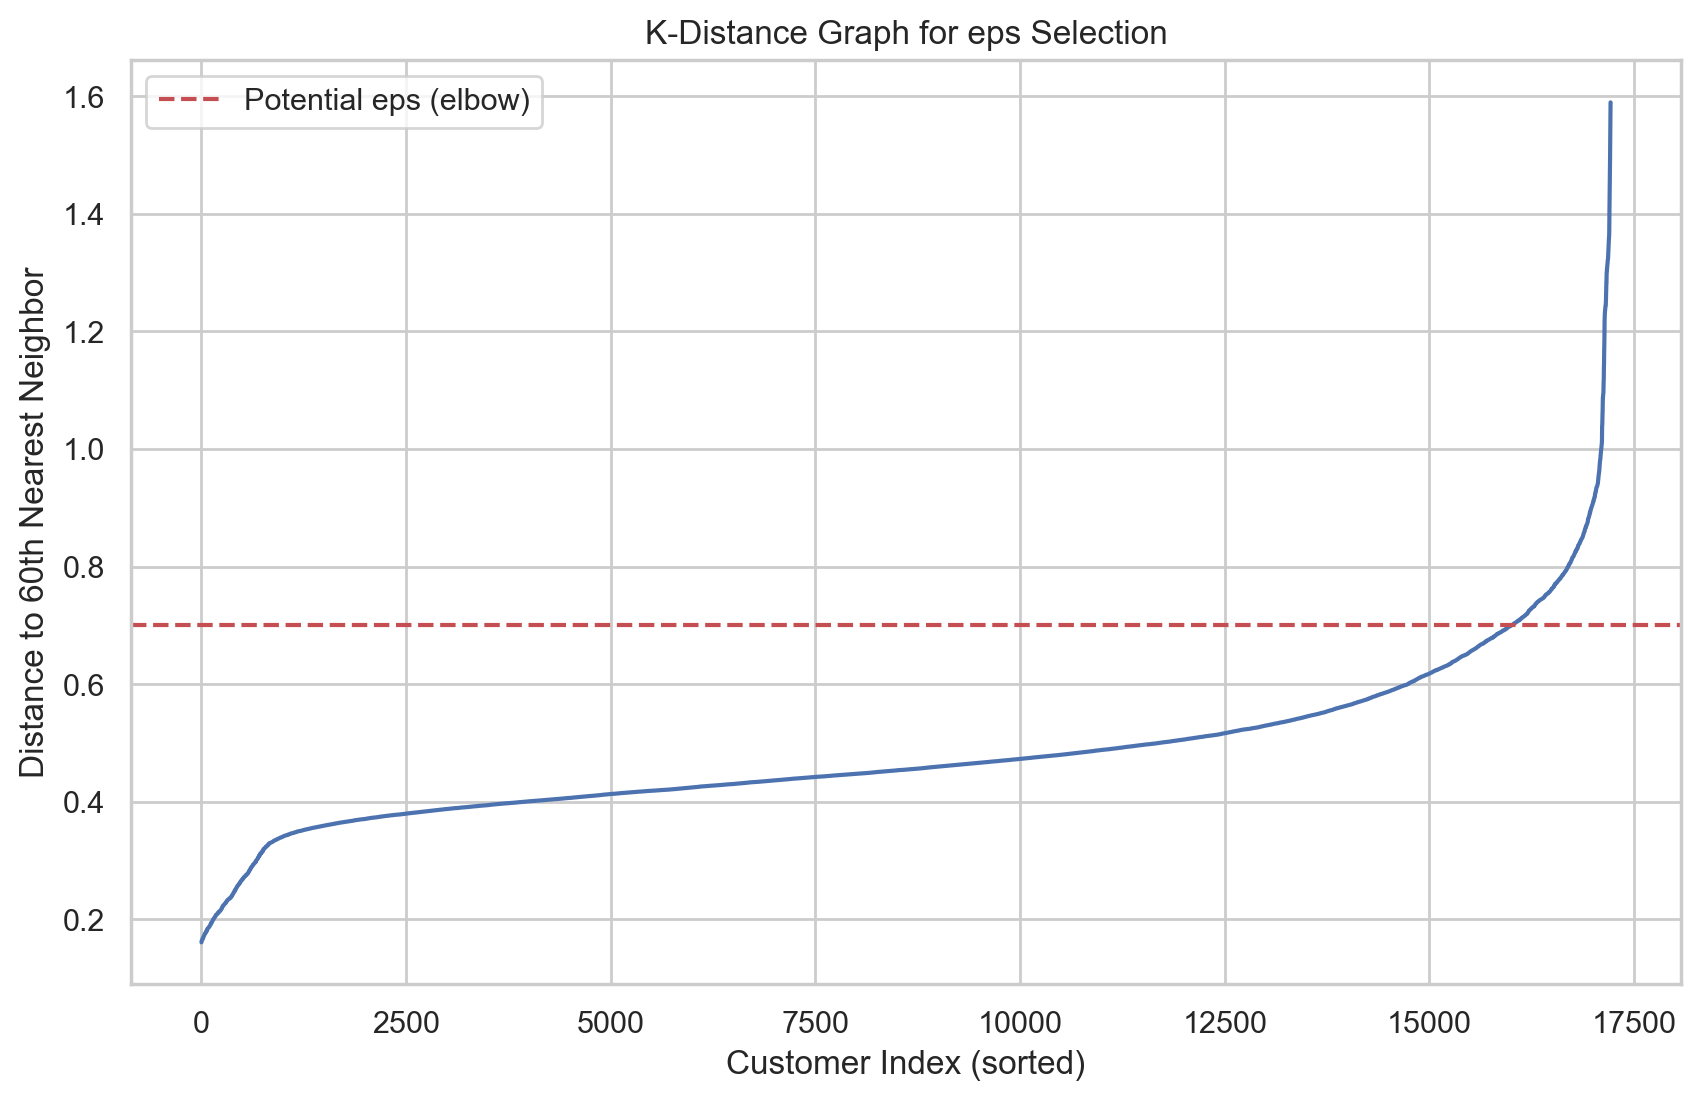

In [49]:
# Find optimal eps using K-distance method
neigh = NearestNeighbors(n_neighbors=58) # n_features * 2 as a rule of thumb
neigh.fit(numeric_dataset)
distances, _ = neigh.kneighbors(numeric_dataset)
# matrix of n_samples x n_neighbors nearest neighbors distances
distances = np.sort(distances[:, -1])
# distances for every sample to the 20th nearest neighbor, sorted

# Plot K-distance graph
plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer Index (sorted)")
plt.ylabel("Distance to 60th Nearest Neighbor")
plt.grid(True)

# Mark potential eps values based on visual inspection
plt.axhline(y=0.7, color='r', linestyle='--', label='Potential eps (elbow)')

plt.legend()
plt.show()

We can notice that the elbow is around 0.6 and because of that we will assume that epsilon = 0.6.

In [50]:
# Remove outliers using DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=58, n_jobs=4)
#n_jobs: limits the algorithm to use 4 cores, which can speed up computations for large datasets.
dbscan_labels = dbscan.fit_predict(numeric_dataset)
Counter(dbscan_labels)

Counter({np.int64(0): 14179,
         np.int64(1): 1265,
         np.int64(2): 993,
         np.int64(3): 588,
         np.int64(-1): 189})

In [51]:
# Check outlier count
outlier_count = Counter(dbscan_labels)
print(f"DBSCAN results: {outlier_count}")
print(f"Outliers detected: {outlier_count[-1]}")
print(f"Total: {sum(outlier_count.values())}")

# Save outliers for later classification
outlier_df = numeric_dataset[dbscan_labels == -1].copy()

# Assign dataset without outliers
dataset_no_outliers = numeric_dataset[dbscan_labels != -1].copy()
print(f"Outliers saved for later: {len(outlier_df)}")

DBSCAN results: Counter({np.int64(0): 14179, np.int64(1): 1265, np.int64(2): 993, np.int64(3): 588, np.int64(-1): 189})
Outliers detected: 189
Total: 17214
Outliers saved for later: 189


In [52]:
print('Percentage of data kept after removing outliers:', np.round(dataset_no_outliers.shape[0] / numeric_dataset.shape[0], 4)*100, '%')

Percentage of data kept after removing outliers: 98.9 %


<a class="anchor" id="6">

# **6. Feature Selection**

[Back to TOP](#TOP)
</a>

In [53]:
# Define binary columns to be removed for clustering
binary_cols = ['Did_Travel', 'Only_Travel_With_Companions', 'Is_Active']
cluster_dataset = dataset_no_outliers.drop(columns=binary_cols)

<a class="anchor" id="6_1">

## **6.1.** Correlation Matrix

[Back to TOP](#TOP)
</a>

We now move on to the feature selection stage, where we visualize a correlation heatmap to understand which features should be kept or removed.
From this heatmap, we can analyze the relationships between variables and identify features that are unlikely to contribute meaningfully to the model. Features with very low correlation to all others may be considered irrelevant, while those with very high correlation may introduce redundancy.
Based on this analysis, we will list the features that we decided to excluded and provide a justification for their removal.

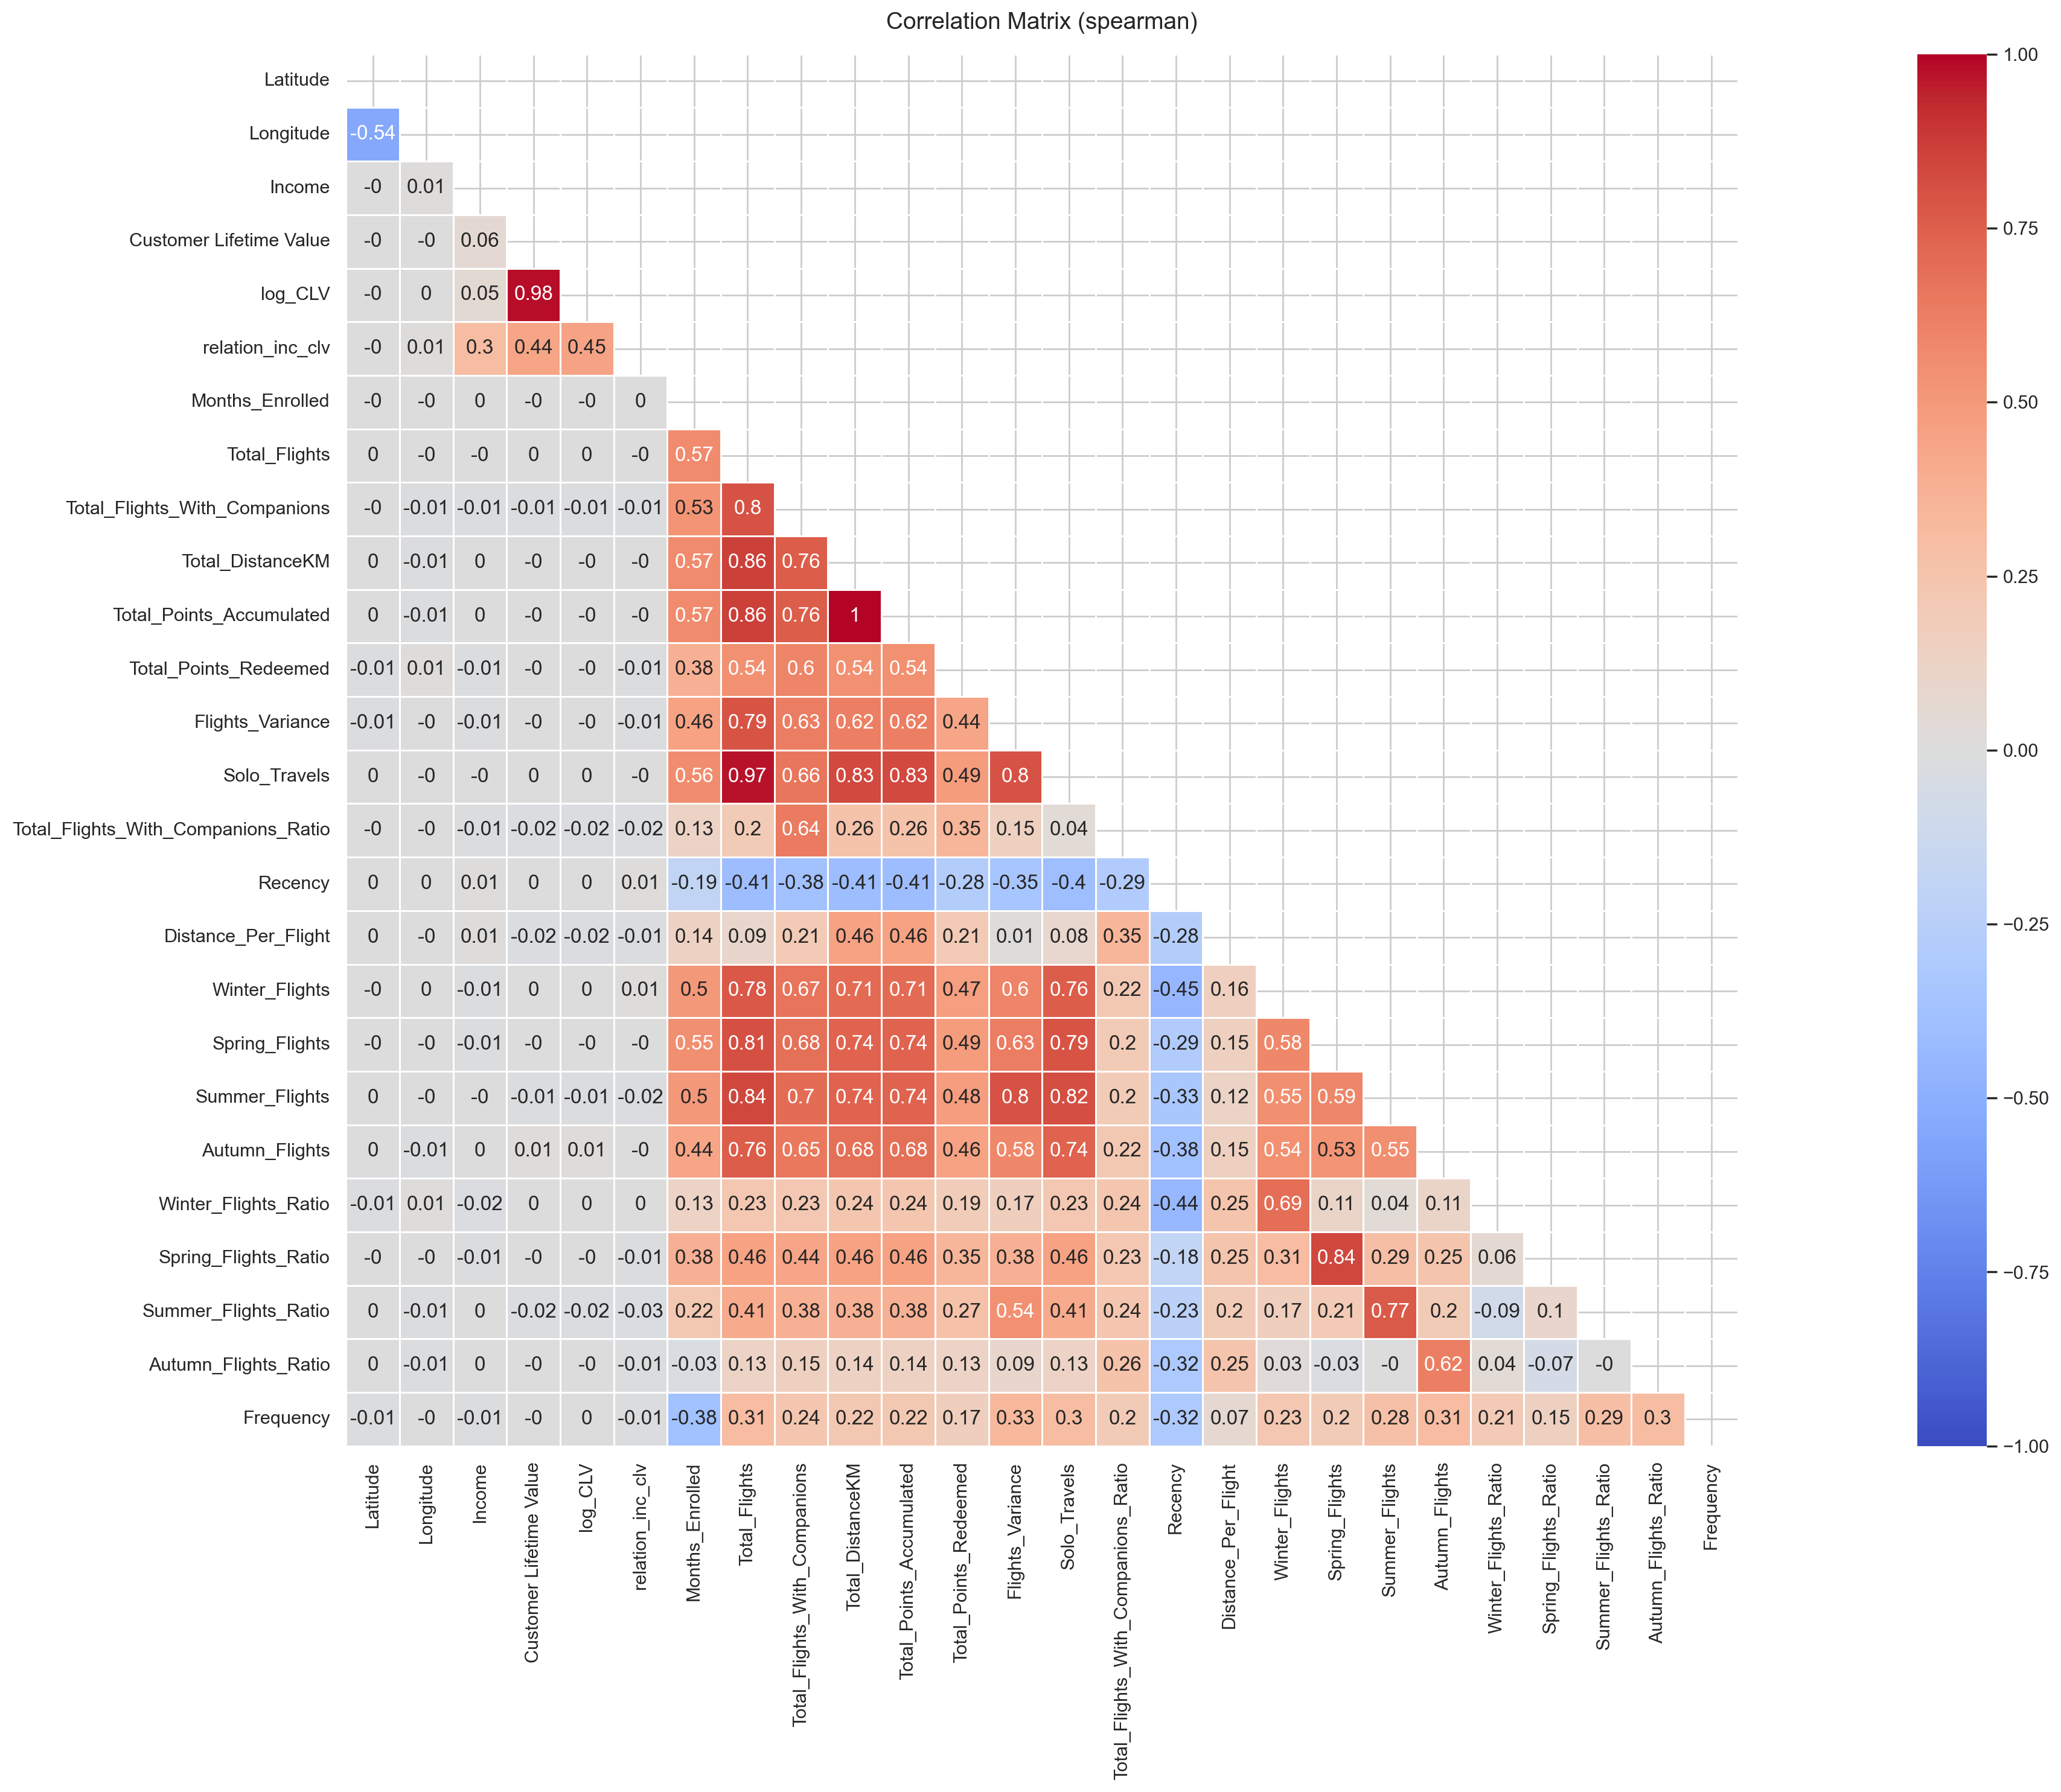

In [54]:
create_heatmap(cluster_dataset, method="spearman", figsize=(30, 15))

In [55]:
high_corr_pairs(cluster_dataset, "spearman", threshold=0.9)

Total_DistanceKM         Total_Points_Accumulated    1.000000
Customer Lifetime Value  log_CLV                     0.981801
Total_Flights            Solo_Travels                0.971355
dtype: float64

Based on the analysis above, we will remove the following features due to high correlation:
- Total_Points_Accumulated
- Log_CLV
- Solo_Travels


From the Heatmap we also decided to remove the low correlated features that follows:
- Latitude
- Longitude
- Summer_Flights
- Autumn_Flights
- Winter_Flights
- Spring_Flights

In [56]:
remove_by_spearman = [
    'Total_Points_Accumulated',
    'log_CLV',
    'Solo_Travels',
    'Latitude',
    'Longitude'
]

cluster_dataset.drop(columns=remove_by_spearman, inplace=True)

<a class="anchor" id="6_2">

## **6.2.** Univariance

[Back to TOP](#TOP)
</a>

In [57]:
# Calculate and display variance of numeric features rounded to 5 decimal places
round(cluster_dataset.var(), 5)

Income                                 0.09216
Customer Lifetime Value                0.01294
relation_inc_clv                       0.00682
Months_Enrolled                        0.03019
Total_Flights                          0.02438
Total_Flights_With_Companions          0.02618
Total_DistanceKM                       0.02642
Total_Points_Redeemed                  0.02314
Flights_Variance                       0.04433
Total_Flights_With_Companions_Ratio    0.01566
Recency                                0.08323
Distance_Per_Flight                    0.00058
Winter_Flights                         0.02391
Spring_Flights                         0.02385
Summer_Flights                         0.02122
Autumn_Flights                         0.02373
Winter_Flights_Ratio                   0.02610
Spring_Flights_Ratio                   0.01940
Summer_Flights_Ratio                   0.02659
Autumn_Flights_Ratio                   0.02810
Frequency                              0.00096
dtype: float6

The  features that we decided to removed due to low variance are:
- relation_inc_clv
- Distance_Per_Flight
- Frequency

It was also decided to remover the features:

- Summer_Flights
- Winter_Flights
- Autumn_Flights
- Spring_flights

This removal was done because These variables mainly reflect the total flight volume of each customer and are therefore highly correlated with the Total_Flights feature. Since seasonal flight ratios were already included to capture relative seasonal travel patterns, keeping the absolute seasonal counts would introduce redundancy without adding new behavioral information.

In [58]:
remove_by_variance = [
    'relation_inc_clv',
    'Distance_Per_Flight',
    'Frequency',
    'Summer_Flights',
    'Winter_Flights',
    'Autumn_Flights',
    'Spring_Flights'
]
cluster_dataset.drop(columns=remove_by_variance, inplace=True)

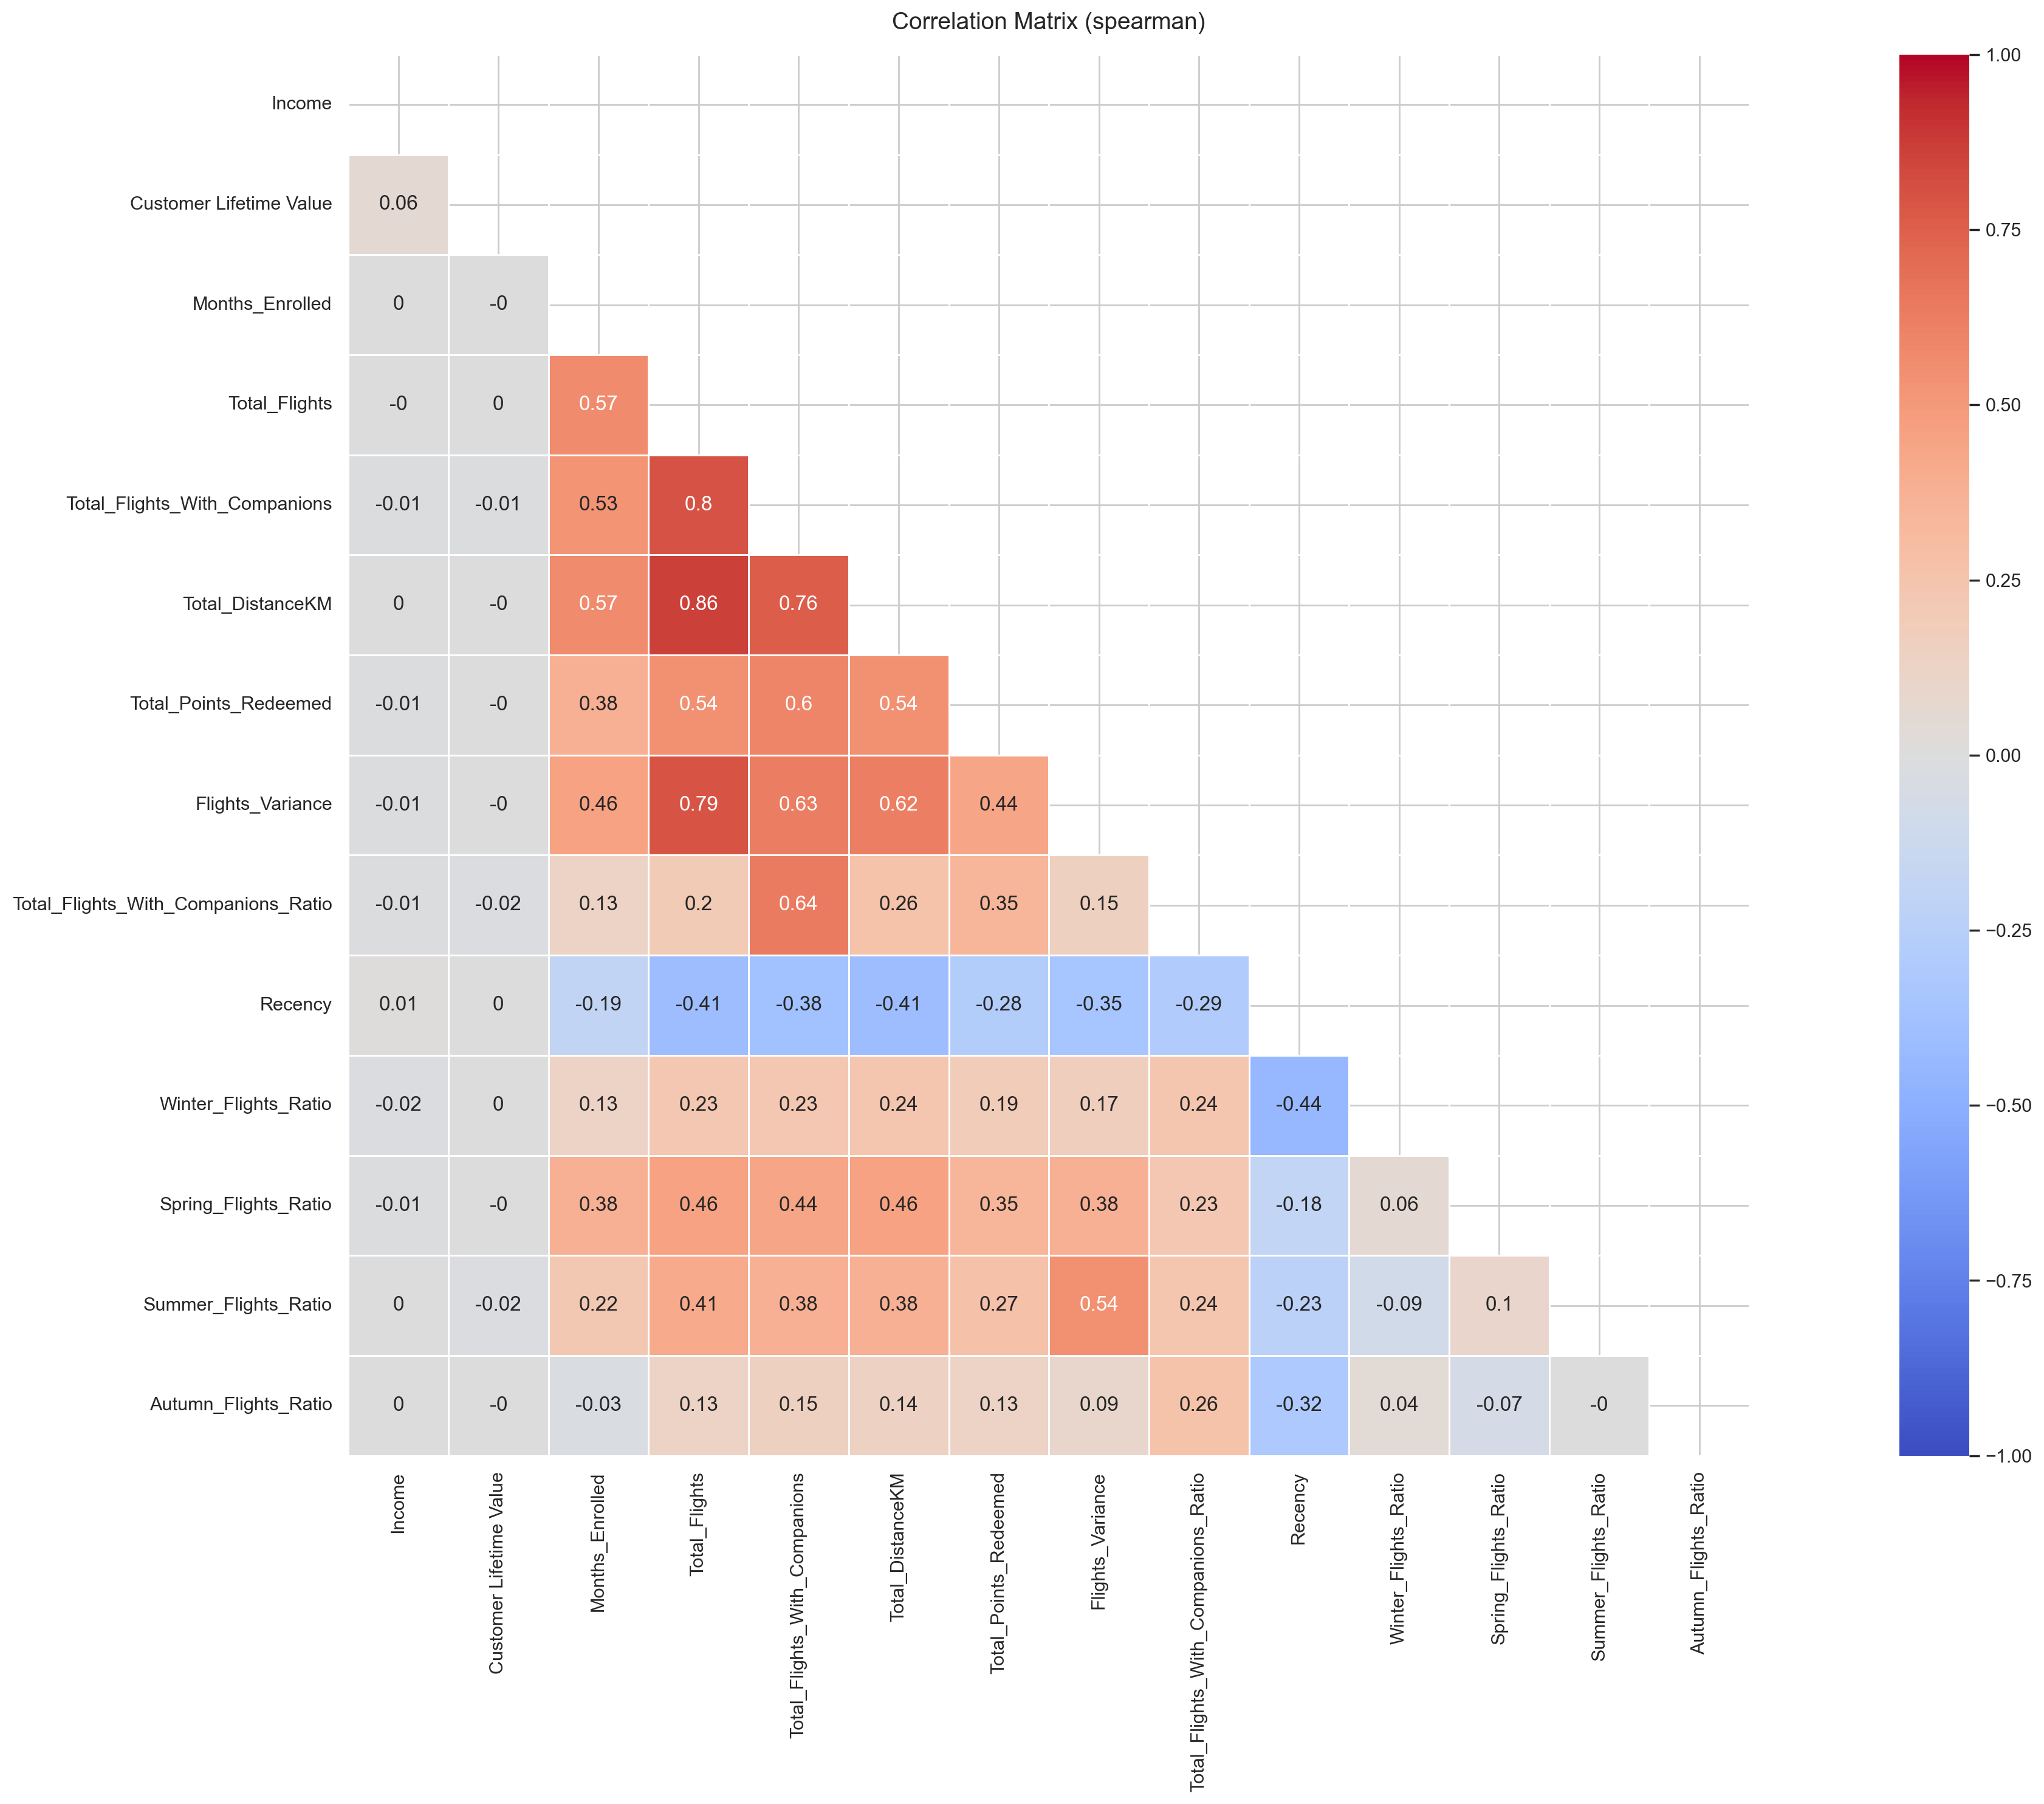

In [59]:
create_heatmap(cluster_dataset, method="spearman", figsize=(25, 15))

<a class="anchor" id="7">

# **7. Clustering**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_1">

## **7.1.** Defining Perspectives

[Back to TOP](#TOP)
</a>

After reviewing the data correlations and aligning with the business goals, we refined our strategy and decided to separate our analysis into two distinct perspectives:
- Value & Engagement profile (identifying who the customer is and how they behave)
- Patters and preferences (analyzing their travel style and choices) 

This approach ensures that our segments are not just statistically significant, but also meaningful for the marketing strategy. This allows us to identify high-potential customers regardless of their current flight frequency.

### Perspective 1: Customer Value & Engagement Profile
To determine the economic value, loyalty, and potential of the customer. This perspective combines demographic capacity with behavioral intensity (RFM model).
- Income
- Customer Lifetime Value
- Months_Enrolled
- Total_Flights
- Total_DistanceKM 
- Total_Points_Redeemed 
- Recency 

In [60]:
df_VE = cluster_dataset[['Income', 'Customer Lifetime Value', 'Months_Enrolled', 'Total_Flights', 'Total_DistanceKM', 'Total_Points_Redeemed', 'Recency']]
feats_VE = df_VE.columns.tolist()

### Perspective 2: Patterns & Preferences
To understand the style of travel and lifestyle preferences, independent of the customer's tier or value. This perspective examines individual habits regarding how and when customers use the service.
- Winter_Flights_Ratio
- Spring_Flights_Ratio
- Summer_Flights_Ratio
- Autumn_Flights_Ratio 
- Flights_Variance
- Total_Flights_With_Companions_Ratio
- Total_Flights_With_Companions

In [61]:
df_PP = cluster_dataset[['Winter_Flights_Ratio', 'Spring_Flights_Ratio', 'Summer_Flights_Ratio', 'Autumn_Flights_Ratio', 'Flights_Variance', 'Total_Flights_With_Companions_Ratio', 'Total_Flights_With_Companions']]
feats_PP = df_PP.columns.tolist()

<a class="anchor" id="7_2">

## **7.2.** Clustering for Customer Value & Engagement Profile Perspective

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3">

## **7.3.** Clustering for Patterns & Preferences Perspective

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_2">

### 7.3.3. Self-Organizing Map

[Back to TOP](#TOP)
</a>

In [62]:
# Total number of clients 
print(f"Total number of clients: {len(cluster_dataset)}")

Total number of clients: 17025


### Defining the Grid Topology

Before training the Self-Organizing Map (SOM), it is crucial to define the optimal dimensions of the output grid. To determine the grid size, we apply the heuristic rule suggested by Vesanto et al., which relates the number of neurons ($N$) to the number of observations ($OBS$) in the dataset:

$$N \approx 5 \sqrt{OBS}$$

Given our pre-processed dataset:
* **Total Customers ($N$):** 17048

**Calculation:**
1.  **Target Number of Neurons:**
    $$N = 5 \times \sqrt{17048} \approx 5 \times 130.57 \approx 652.8$$

2.  **Grid Dimensions:**
    To create a square grid ($x \times y$), we calculate the square root of $N$:
    $$\sqrt{652.8} \approx 25.55$$

**Conclusion:**
Rounding up to the nearest integer to ensure sufficient capacity, we will initialize a **26 $\times$ 26** grid (totaling 676 neurons). This topology provides a robust structure to project the high-dimensional customer data into a 2D feature map.

In [103]:
som_data = df_VE.values 

sm = MiniSom(
             x=26, 
             y=26, 
             input_len=som_data.shape[1],
             sigma=2.0,
             learning_rate=0.5,
             neighborhood_function='gaussian',
             random_seed=42
             )

sm.train_random(som_data, num_iteration=17048*5, verbose=True)

te = sm.topographic_error(som_data)
print(f"Topographic Error: {te:.5f}")

 [ 85240 / 85240 ] 100% - 0:00:00 left 
 quantization error: 0.10724166630567264
Topographic Error: 0.13151


In [64]:
weights_som = sm.get_weights()

In [65]:
def plot_hexagons_ax(
    som,
    ax,
    matrix_vals,
    colornorm,
    label="",
    cmap=plt.cm.Grays,
    annot=False
):
    # draw hexagons
    for i in range(matrix_vals.shape[0]):
        for j in range(matrix_vals.shape[1]):
            x, y = som.convert_map_to_euclidean((i, j))
            val = matrix_vals[i, j]

            ax.add_patch(
                RegularPolygon(
                    (x, y),
                    numVertices=6,
                    radius=np.sqrt(1 / 3),
                    facecolor=cmap(colornorm(val)),
                    edgecolor="white",
                    linewidth=0.5
                )
            )
            # add annotation
            if annot:
                txt = int(val) if val == int(val) else np.round(val, 2)
                ax.text(x, y, txt, ha="center", va="center", fontsize="x-small")

    # styling
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(label, fontsize=7.5, pad=6)
    ax.margins(0.05)

    # create colorbar axis
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.04)

    # create colorbar
    sm = plt.cm.ScalarMappable(norm=colornorm, cmap=cmap)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cax)
    cb.ax.tick_params(labelsize=7)

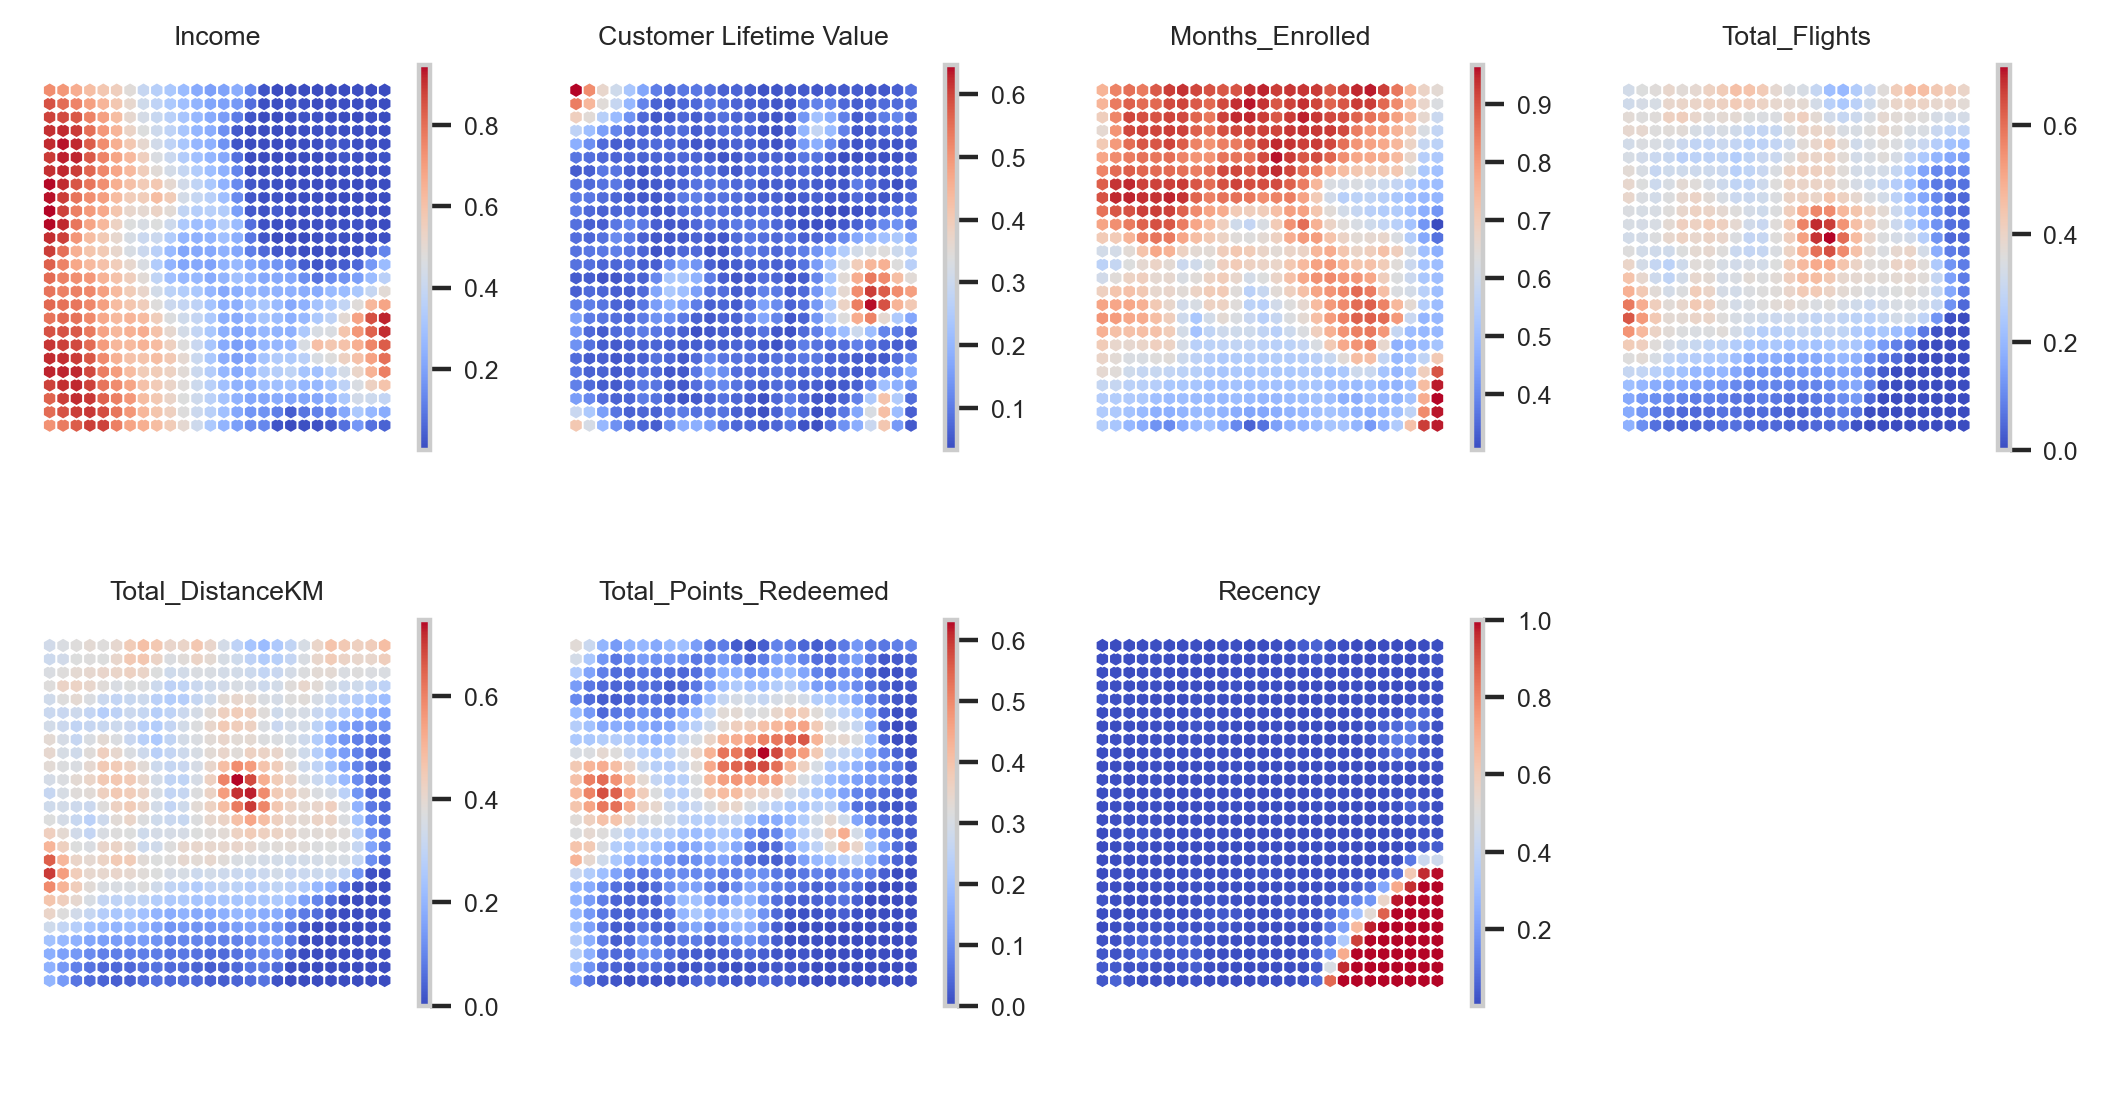

In [108]:
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5.5), dpi=128, constrained_layout=False)
fig.subplots_adjust(hspace=0.05, wspace=0.3)

axes = axes.flatten()

for i, feat in enumerate(feats_VE):
    ax = axes[i]
    matrix_vals = weights_som[:, :, i]

    norm = mpl_colors.Normalize(vmin=matrix_vals.min(), vmax=matrix_vals.max())

    plot_hexagons_ax(
        som=sm,
        ax=ax,
        matrix_vals=matrix_vals,
        colornorm=norm,
        label=feat,
        cmap=cm.coolwarm,
        annot=False
    )

# turn off any leftover axes if feats_VE < nrows*ncols
for ax in axes[len(feats_VE):]:
    ax.axis("off")

plt.show()

In [67]:
umatrix = sm.distance_map(scaling='mean')

## Flip and rotate to match plot
print(np.flip(np.round(umatrix,2), axis=1).T)

[[0.34 0.43 0.48 0.48 0.51 0.55 0.55 0.63 0.56 0.6  0.56 0.5  0.49 0.43
  0.45 0.4  0.39 0.34 0.44 0.66 0.69 0.53 0.47 0.46 0.34]
 [0.4  0.43 0.45 0.49 0.54 0.52 0.53 0.52 0.54 0.55 0.5  0.44 0.42 0.41
  0.43 0.46 0.38 0.38 0.42 0.62 0.69 0.57 0.61 0.59 0.59]
 [0.39 0.39 0.44 0.53 0.54 0.49 0.47 0.43 0.43 0.4  0.37 0.35 0.34 0.37
  0.42 0.44 0.37 0.35 0.43 0.6  0.61 0.61 0.69 0.71 0.69]
 [0.41 0.42 0.44 0.47 0.47 0.43 0.38 0.38 0.36 0.33 0.27 0.26 0.27 0.3
  0.35 0.39 0.33 0.34 0.44 0.51 0.5  0.52 0.55 0.6  0.63]
 [0.41 0.4  0.4  0.38 0.36 0.33 0.31 0.33 0.31 0.3  0.27 0.26 0.24 0.25
  0.28 0.31 0.32 0.34 0.41 0.44 0.48 0.45 0.47 0.51 0.56]
 [0.37 0.35 0.33 0.29 0.28 0.28 0.26 0.26 0.32 0.33 0.31 0.29 0.27 0.26
  0.26 0.27 0.31 0.32 0.33 0.39 0.4  0.45 0.48 0.5  0.57]
 [0.32 0.33 0.29 0.25 0.24 0.24 0.25 0.27 0.3  0.33 0.33 0.33 0.33 0.3
  0.26 0.24 0.29 0.29 0.32 0.36 0.38 0.49 0.53 0.49 0.48]
 [0.38 0.36 0.31 0.26 0.24 0.24 0.26 0.29 0.31 0.29 0.31 0.28 0.31 0.3
  0.29 0.26 0.27 0.32

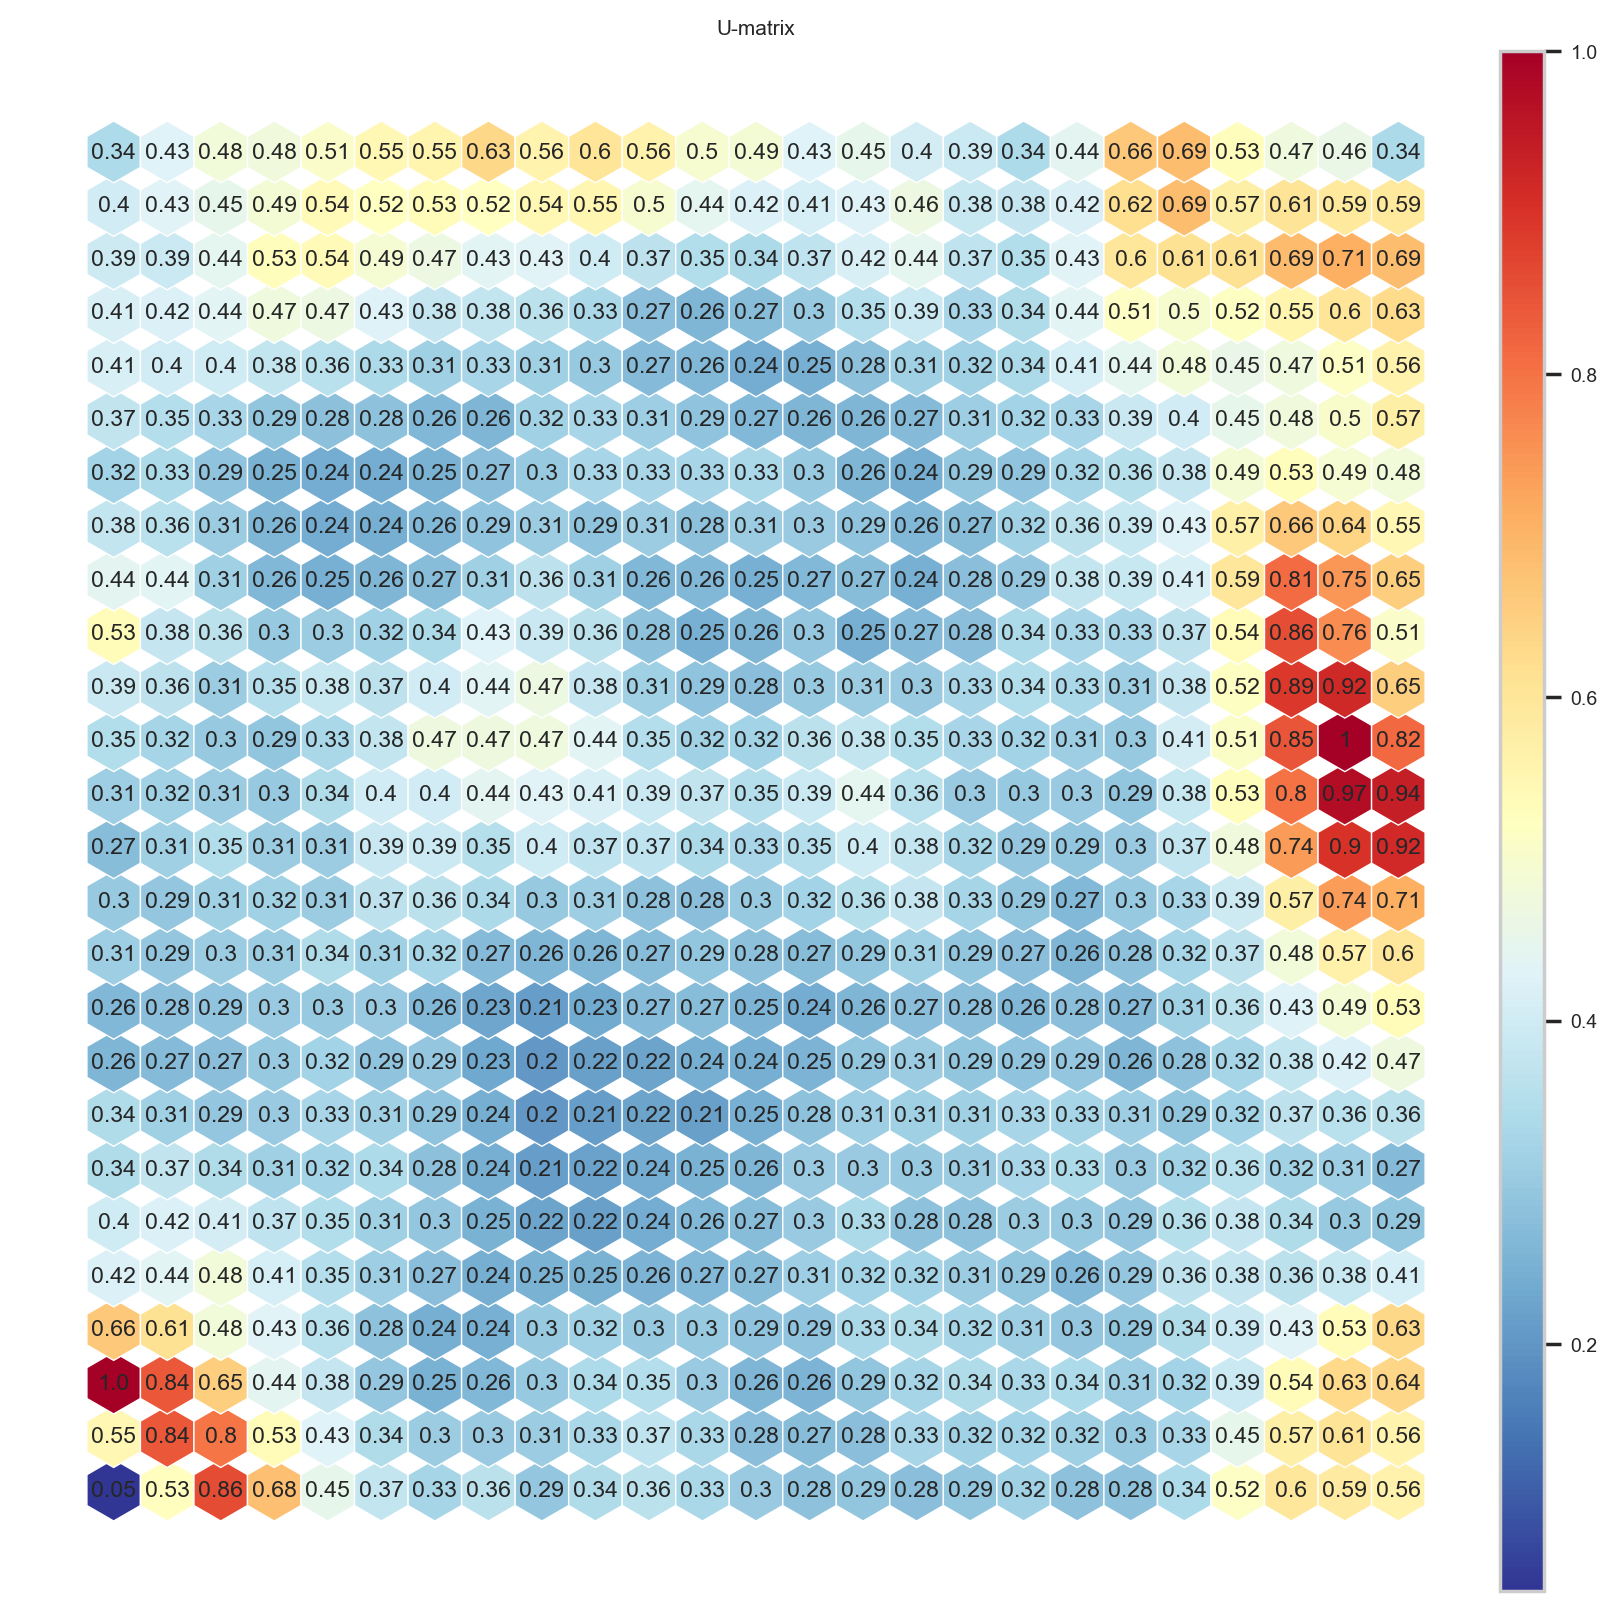

In [69]:
# Criar a figura e o eixo manualmente para a U-Matrix
fig, ax = plt.subplots(figsize=(13, 10))

# Chamar a função CORRETA que definiste acima (com _ax)
plot_hexagons_ax(
    som=sm,
    ax=ax,  # Passar o eixo aqui
    matrix_vals=umatrix,
    colornorm=mpl_colors.Normalize(
        vmin=umatrix.min(),
        vmax=umatrix.max()
    ),
    label="U-matrix",
    cmap=cm.RdYlBu_r,
    annot=True
)

plt.show()

## Hitmap

In [70]:
hitsmatrix = sm.activation_response(df_PP.values)

## Values of HITS:
## Flip and rotate to match plot
np.flip(np.round(hitsmatrix,2), axis=1).T

array([[  28.,   29.,   25.,   26.,   21.,   26.,   26.,   20.,   17.,
          18.,   18.,   27.,   21.,   26.,   16.,   30.,   18.,    7.,
          45.,   35.,    5.,   66.,   29.,   40.,   32.],
       [  34.,   19.,   27.,   19.,   22.,   15.,   28.,   12.,   18.,
          14.,   24.,   22.,   17.,   18.,   20.,   16.,   19.,   25.,
          15.,   12.,   10.,   20.,    7.,   11.,   29.],
       [  15.,   10.,    9.,   32.,   20.,   24.,   25.,   21.,   30.,
          18.,   13.,   23.,   16.,   25.,   28.,   31.,   16.,   32.,
          17.,   22.,    4.,   27.,   31.,   24.,   13.],
       [  43.,   23.,   18.,   23.,   34.,   22.,   21.,   28.,   18.,
          22.,   19.,   19.,   18.,   31.,   25.,   21.,   16.,   29.,
          33.,   24.,   10.,   41.,   28.,   25.,   25.],
       [  25.,   24.,   33.,   39.,   20.,   34.,   19.,   32.,   19.,
          22.,   17.,   20.,   11.,   17.,   17.,   15.,   11.,   27.,
          24.,   13.,   27.,    9.,   24.,   24.,   35.],


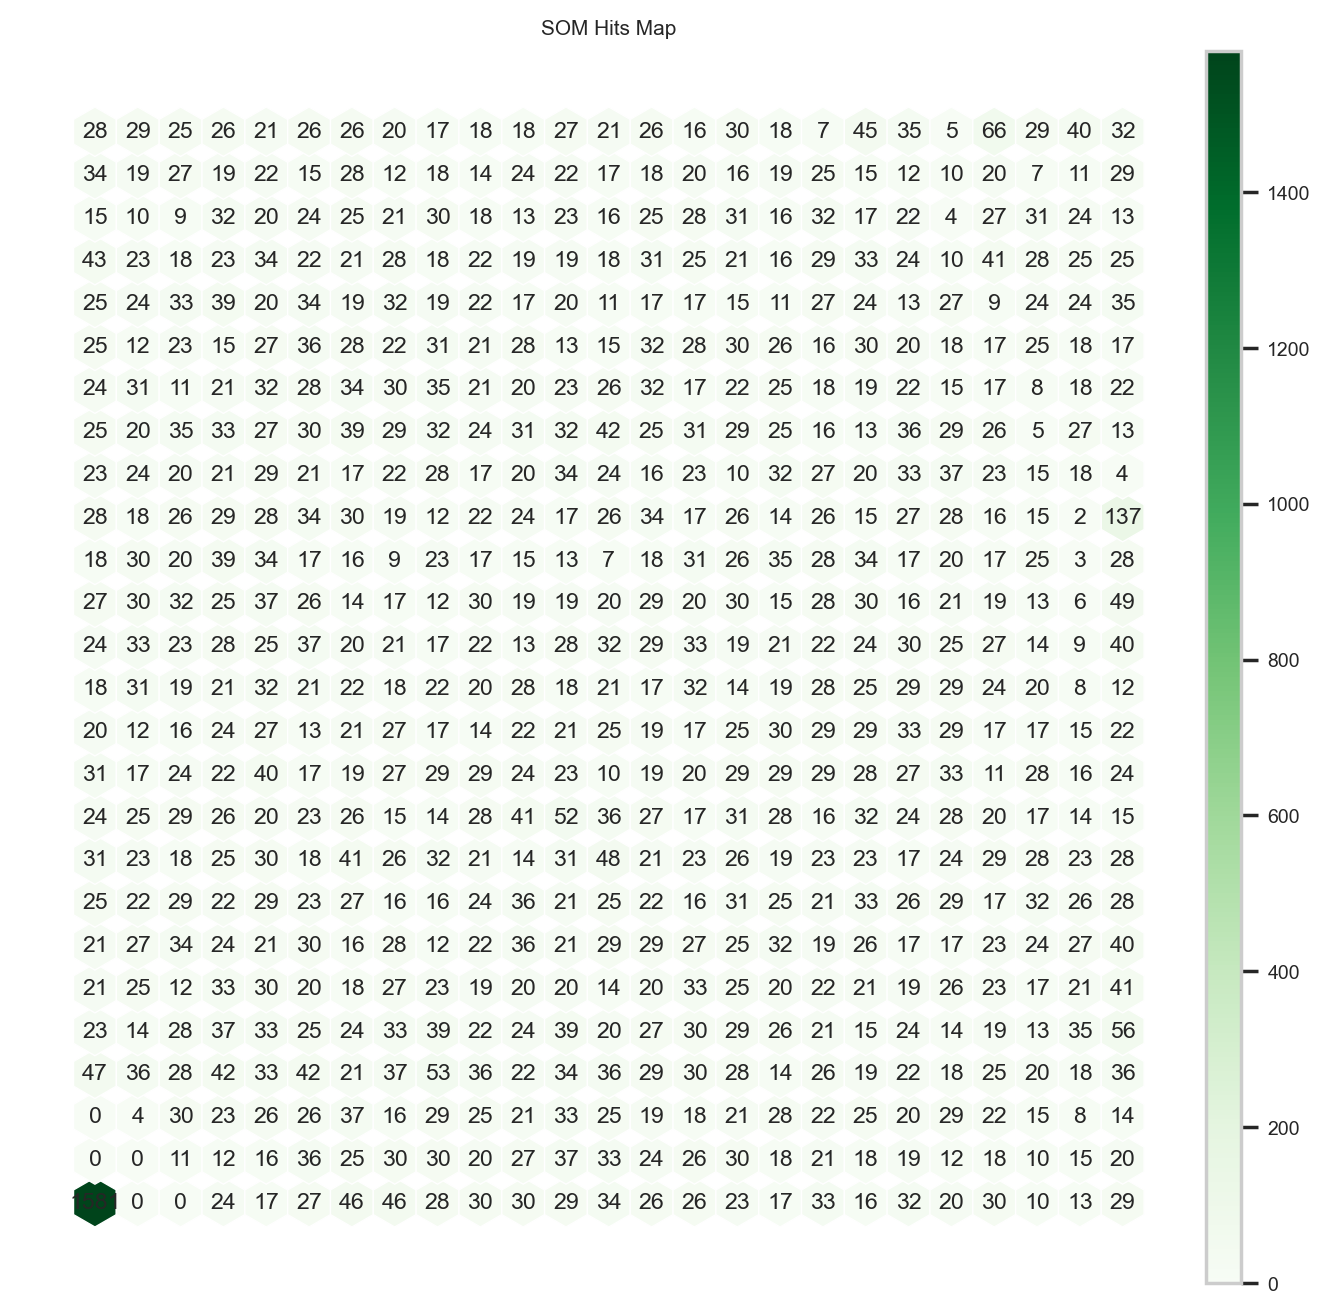

In [72]:
# 1. Preparar a Hits Matrix (se ainda não a tiveres calculado)
# A hits matrix conta quantos pontos de dados caíram em cada neurónio
hitsmatrix = sm.activation_response(som_data)

# 2. Configurar a Normalização
norm = mpl_colors.Normalize(
    vmin=0, 
    vmax=hitsmatrix.max()
)

# 3. Criar a Figura e o Eixo (Necessário para a função _ax)
fig, ax = plt.subplots(figsize=(11, 8))

# 4. Chamar a função adaptada
plot_hexagons_ax(
    som=sm,
    ax=ax,                     # Passamos o eixo criado acima
    matrix_vals=hitsmatrix,
    colornorm=norm,
    label="SOM Hits Map",
    cmap=cm.Greens,            # Tons de verde como pediste
    annot=True                 # Mostra o número de hits em cada hexágono
)

plt.show()

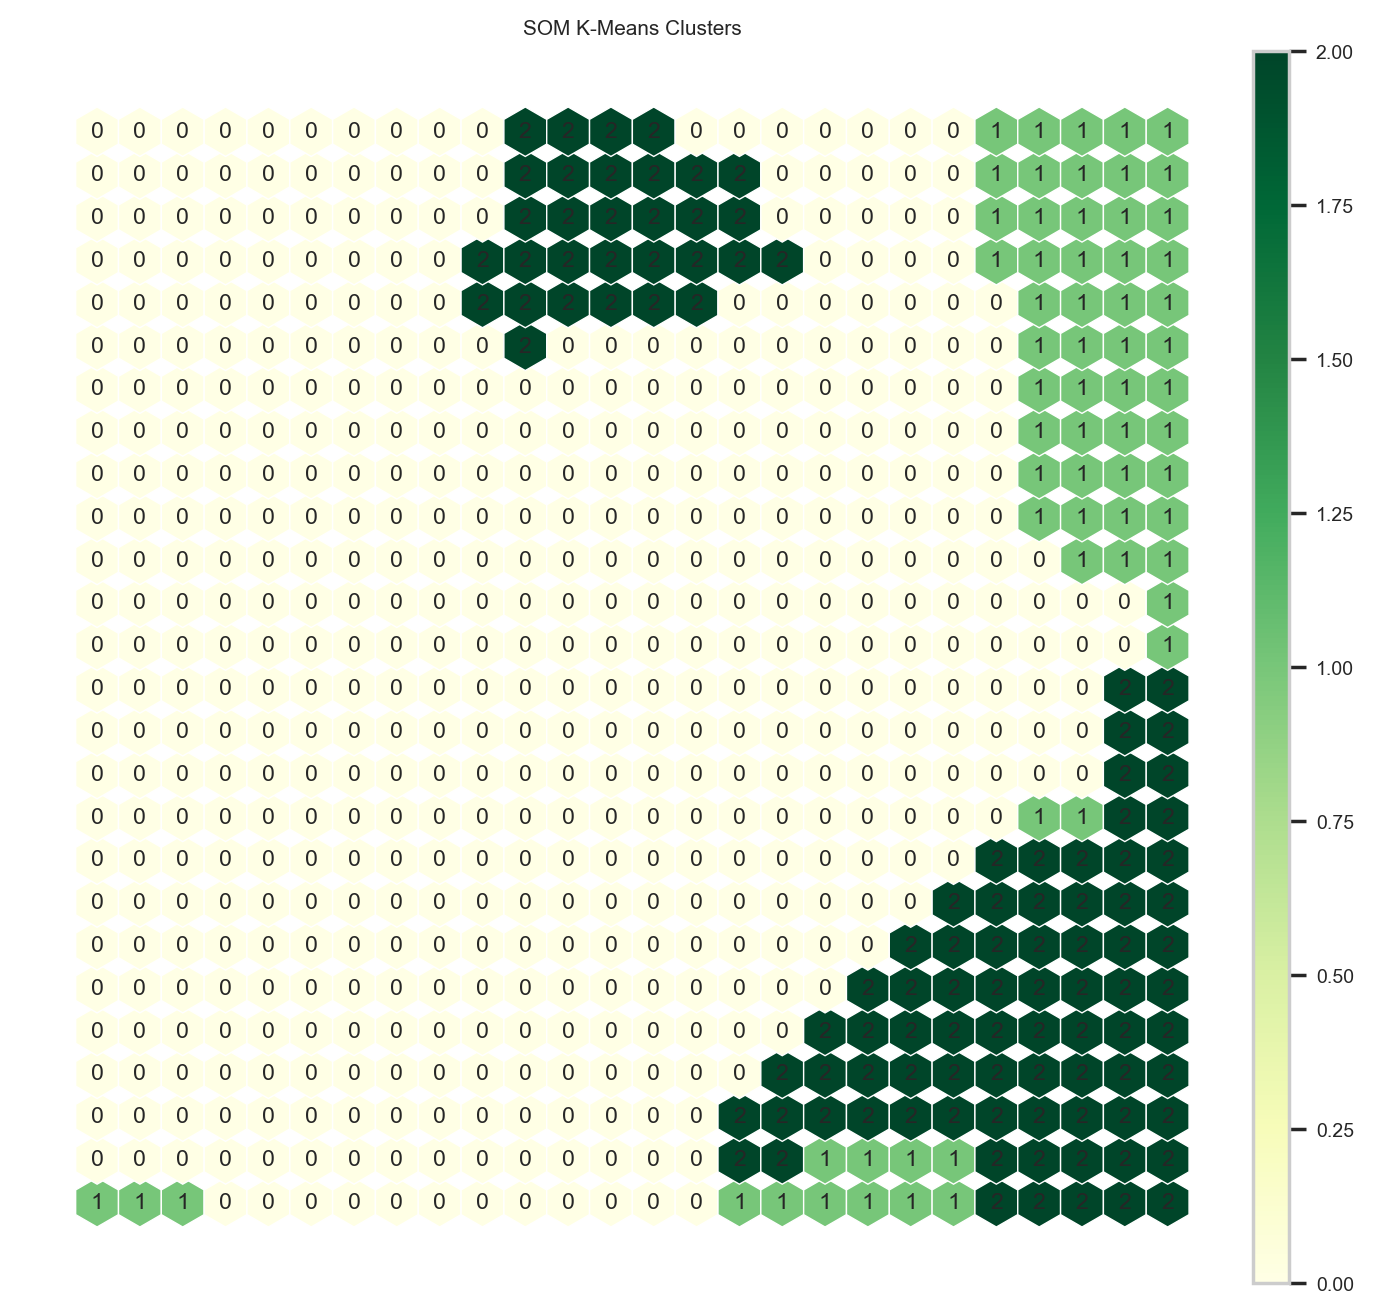

In [90]:
from sklearn.cluster import KMeans

# 1. Obter os pesos e dimensões do mapa
# Usamos o weights_som que já tinhas calculado ou sm.get_weights()
weights = sm.get_weights()
M, N, num_features = weights.shape

# 2. Reshape para o K-Means (Transformar a grelha 2D num array de vetores)
weights_flat = weights.reshape((M * N, num_features))

# 3. Aplicar K-Means
# Definimos 3 clusters como tinhas no teu exemplo
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20, random_state=42)
nodeclus_labels = kmeans.fit_predict(weights_flat)

# 4. Voltar à forma da matriz (M, N) para poder desenhar
kmeans_matrix = nodeclus_labels.reshape((M, N))

# 5. Visualização usando a tua função de hexágonos
# Nota: Como a tua função é 'plot_hexagons_ax', precisamos de criar o 'ax'
fig, ax = plt.subplots(figsize=(11, 8))

norm = mpl_colors.Normalize(vmin=0, vmax=n_clusters - 1)

plot_hexagons_ax(
    som=sm,
    ax=ax,
    matrix_vals=kmeans_matrix,
    colornorm=norm,
    label="SOM K-Means Clusters",
    cmap=cm.YlGn, # Cores pastel para os clusters
    annot=True # Útil para ver qual é o ID do cluster em cada zona
)

plt.show()

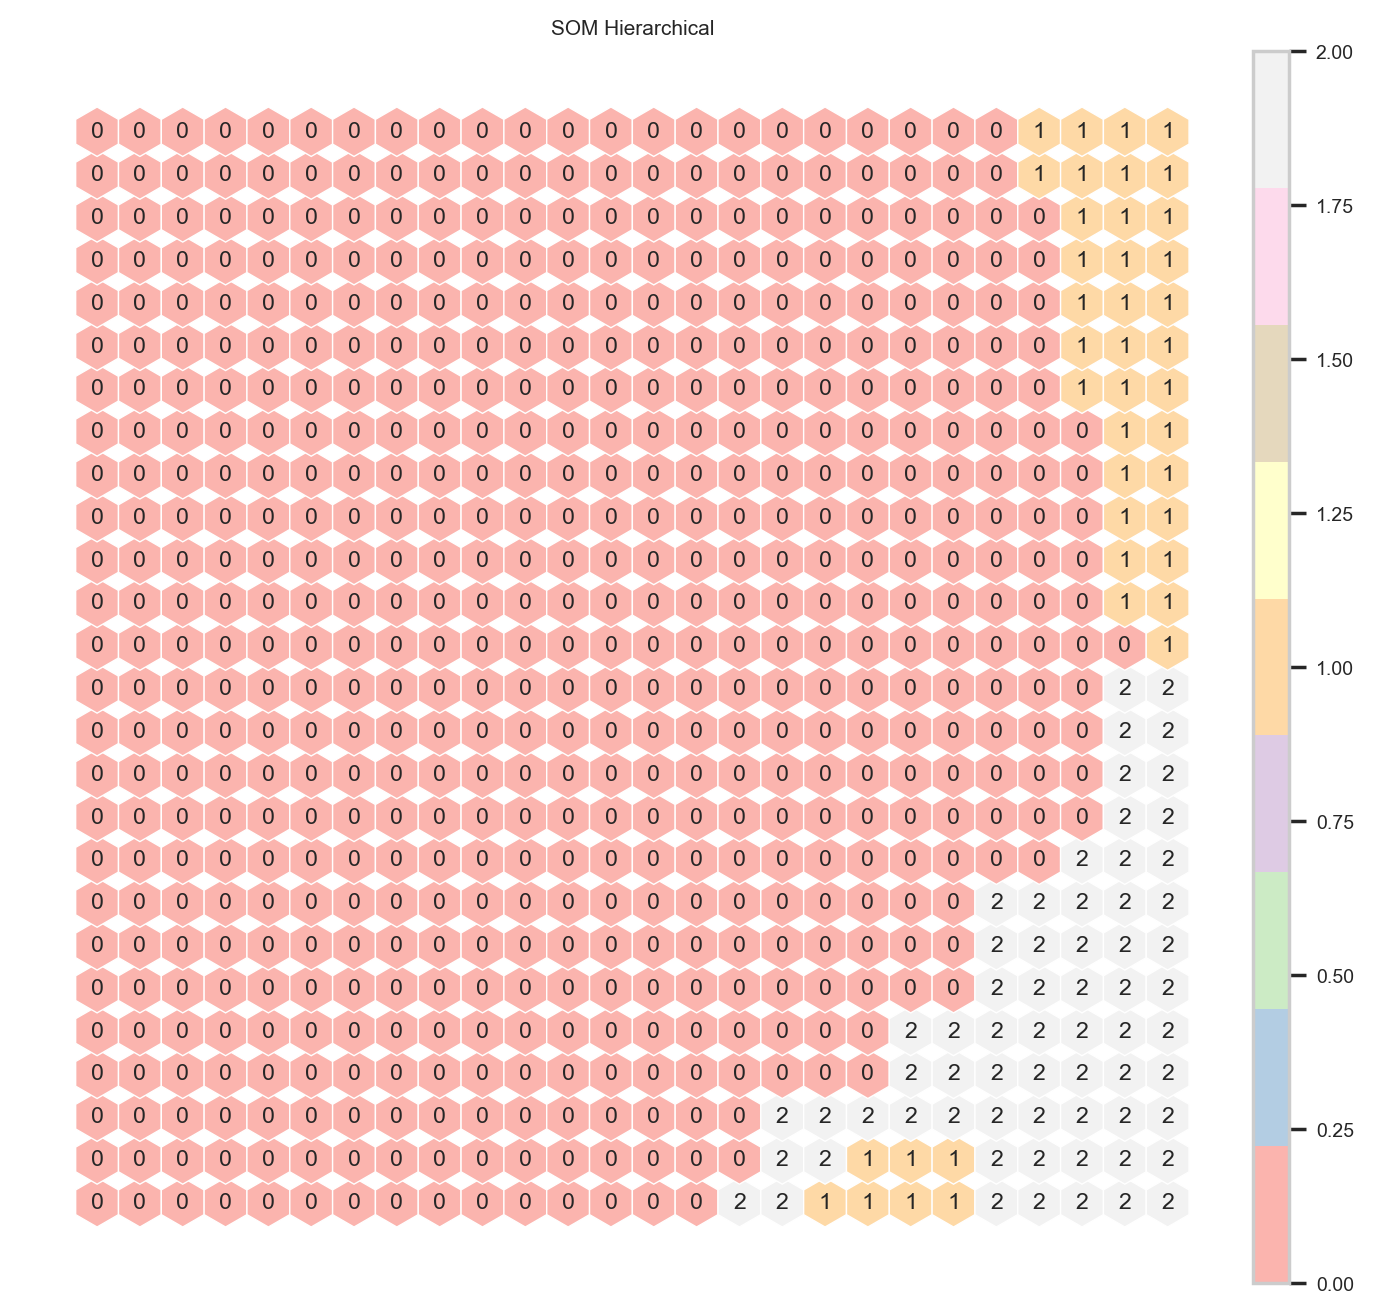

In [88]:
# 1. Criar a figura e o EIXO (ax) corretamente
fig, ax = plt.subplots(figsize=(11, 8))

# 2. Configurar a normalização
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(hclust_matrix))

# 3. Chamar a função com a ordem correta dos argumentos:
# som, ax, matrix_vals, colornorm
plot_hexagons_ax(
    sm,               # som
    ax,               # ax (o eixo onde desenhar)
    hclust_matrix,    # matrix_vals (agora na posição certa com .shape)
    colornorm,        # colornorm
    label="SOM Hierarchical",
    cmap=plt.cm.Pastel1,
    annot=True        # Adicionei True para veres os grupos 0, 1, 2
)

plt.show()

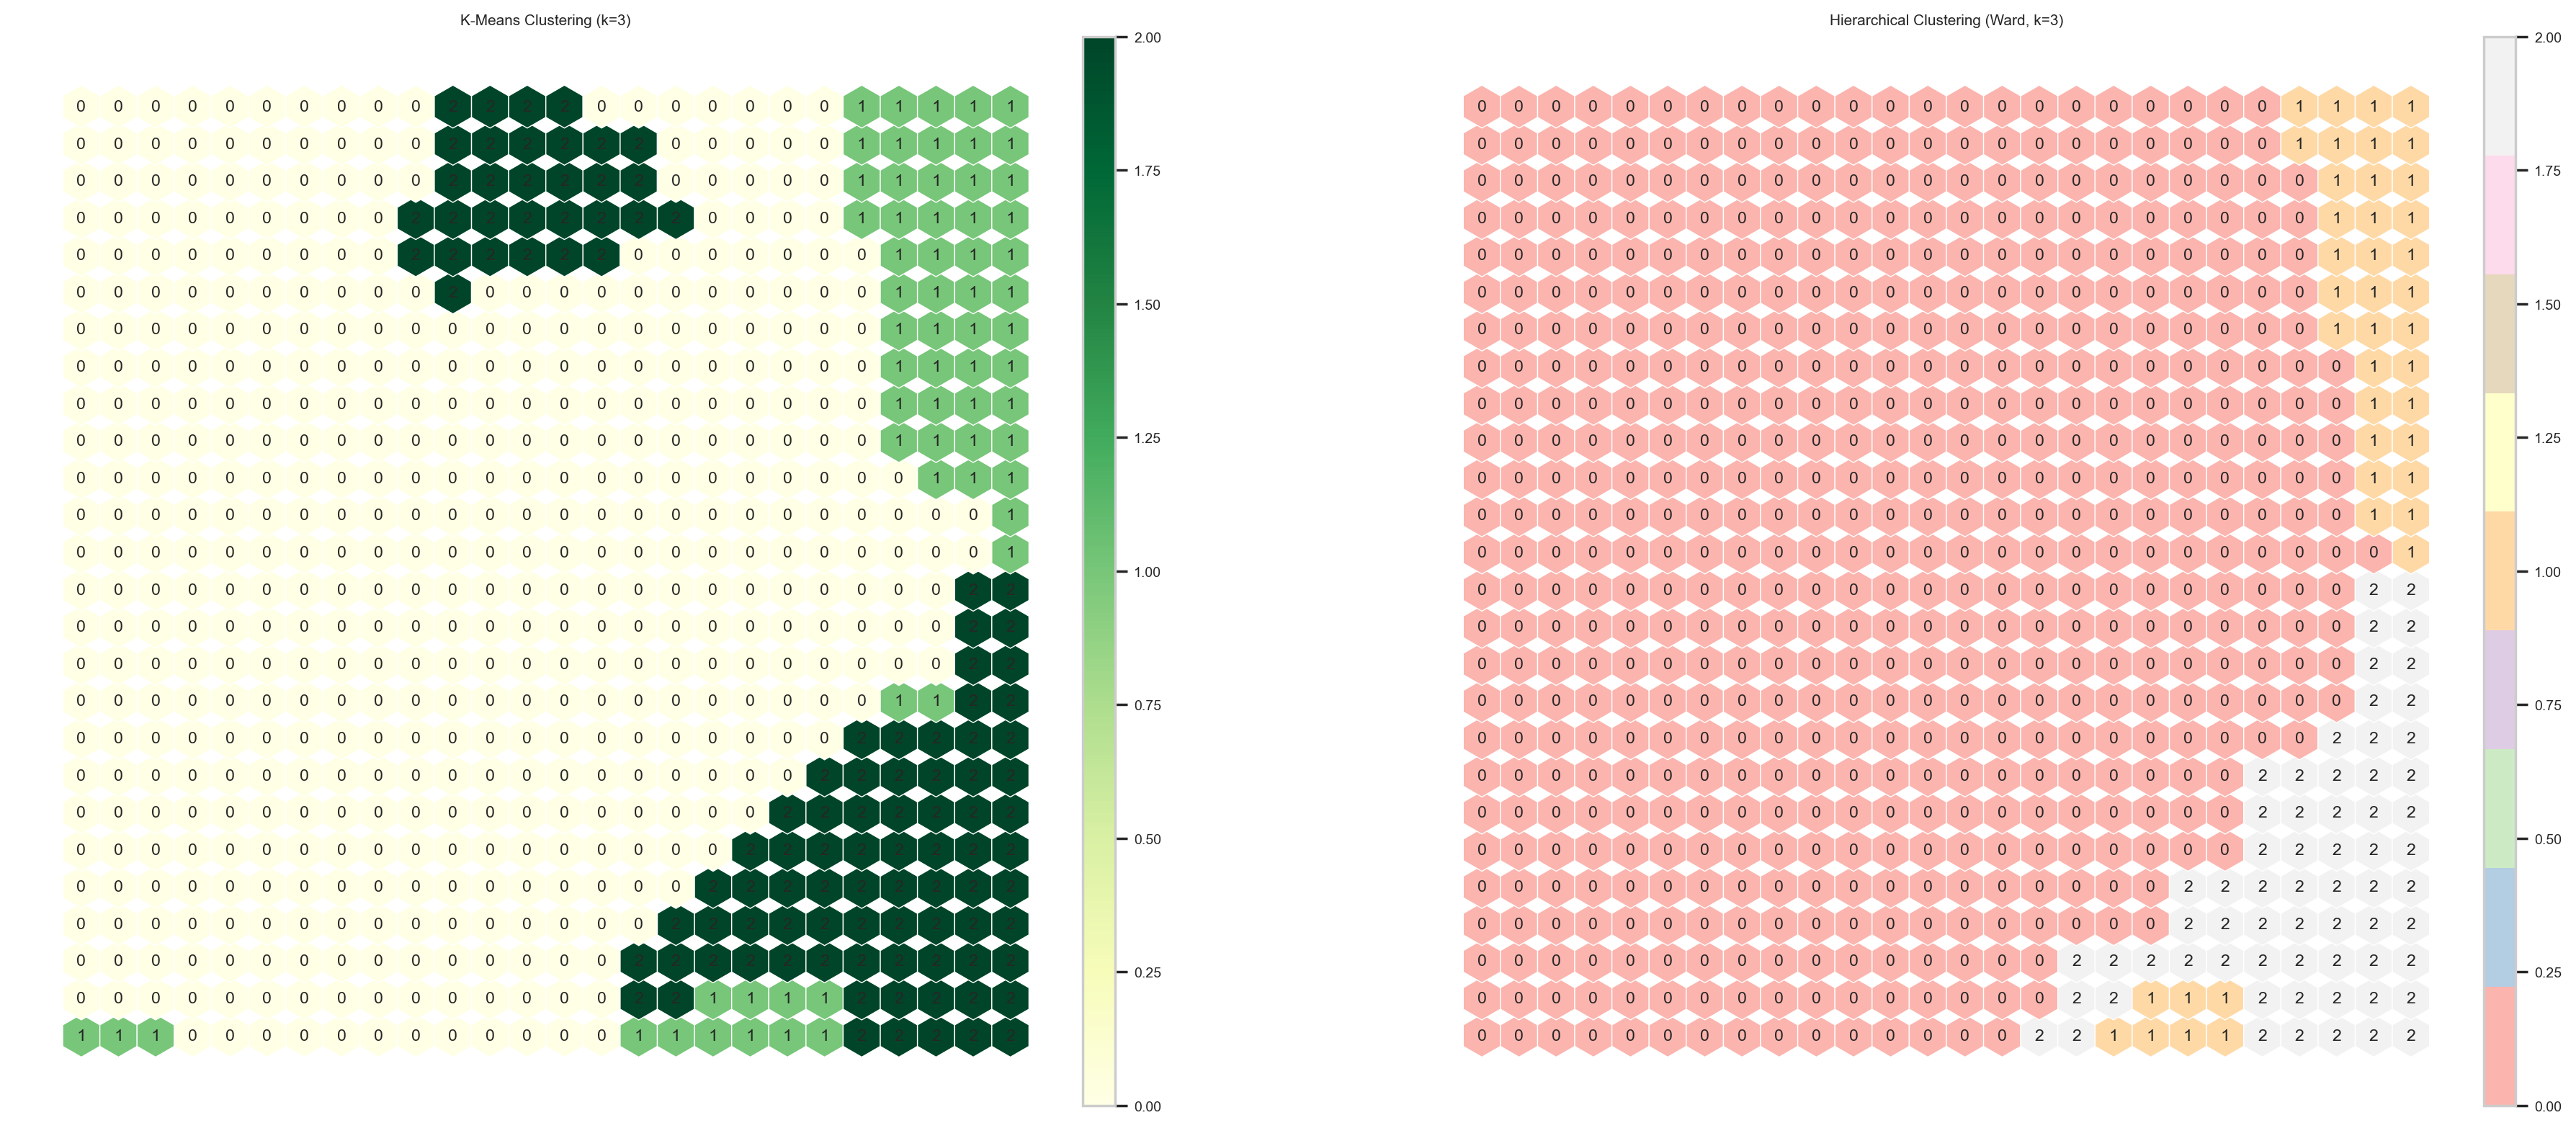

In [92]:
# 1. Configurar o layout com 2 colunas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- CLUSTER 1: K-MEANS ---
# (Assumindo que já calculaste o kmeans_matrix anteriormente)
norm_km = mpl_colors.Normalize(vmin=0, vmax=kmeans_matrix.max())
plot_hexagons_ax(
    sm, 
    ax1, 
    kmeans_matrix, 
    norm_km, 
    label="K-Means Clustering (k=3)", 
    cmap=plt.cm.YlGn, 
    annot=True
)

# --- CLUSTER 2: HIERARCHICAL ---
# (Assumindo que já calculaste o hclust_matrix anteriormente)
norm_hc = mpl_colors.Normalize(vmin=0, vmax=hclust_matrix.max())
plot_hexagons_ax(
    sm, 
    ax2, 
    hclust_matrix, 
    norm_hc, 
    label="Hierarchical Clustering (Ward, k=3)", 
    cmap=plt.cm.Pastel1, 
    annot=True
)

plt.tight_layout()
plt.show()

In [93]:
import pandas as pd

# 1. Encontrar o neurónio vencedor (BMU) para cada cliente
winner_coordinates = np.array([sm.winner(x) for x in som_data]).T

# 2. Mapear as coordenadas (x,y) para o ID do cluster hierárquico
cluster_assignments = []
for x, y in zip(winner_coordinates[0], winner_coordinates[1]):
    cluster_assignments.append(hclust_matrix[x, y])

# 3. Adicionar a coluna de Cluster ao teu DataFrame original
df_final = df_PP.copy()
df_final['Cluster_SOM'] = cluster_assignments

Perfil Médio por Cluster:


,Winter_Flights_Ratio,Spring_Flights_Ratio,Summer_Flights_Ratio,Autumn_Flights_Ratio,Flights_Variance,Total_Flights_With_Companions_Ratio,Total_Flights_With_Companions
Cluster_SOM,,,,,,,
0,0.213312,0.232485,0.324121,0.230082,0.494765,0.245723,0.291707
1,0.199248,0.058895,0.007136,0.027655,0.038817,0.064380,0.014049
2,0.214593,0.097462,0.110291,0.577654,0.205619,0.253513,0.089454


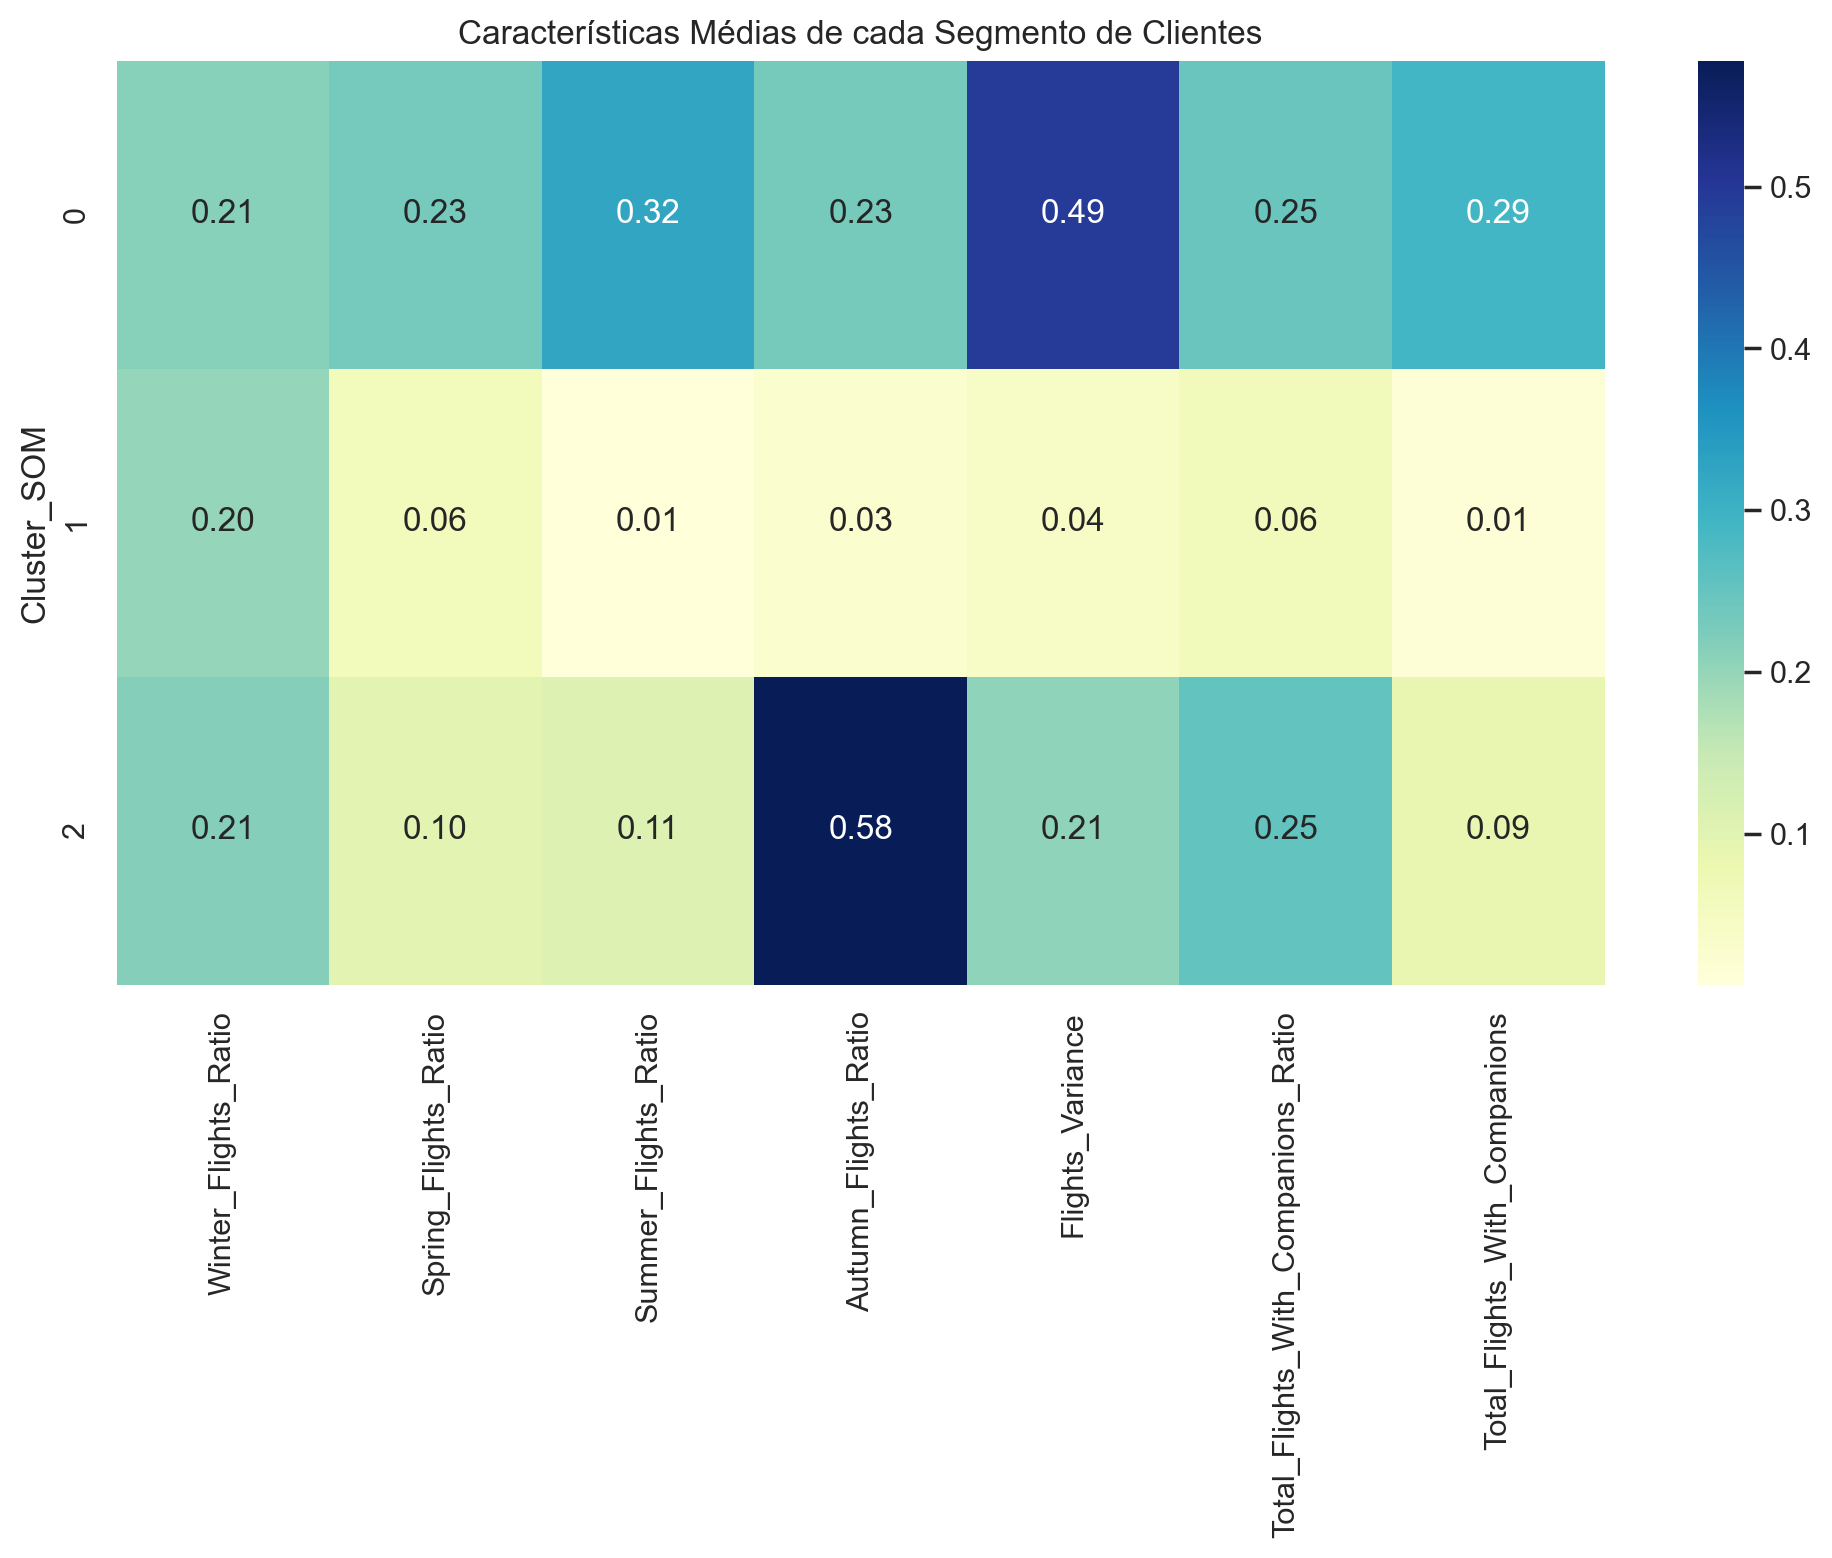

In [99]:
# Calcular as médias por cluster
cluster_profiles = df_final.groupby('Cluster_SOM').mean()

# Mostrar a tabela de perfis
print("Perfil Médio por Cluster:")
display(cluster_profiles)

# Visualização rápida com um Heatmap
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Características Médias de cada Segmento de Clientes')
plt.show()

In [101]:
contagem_clusters = df_final['Cluster_SOM'].value_counts().sort_index()
print("Distribuição de Clientes por Cluster:")
print(contagem_clusters)

Distribuição de Clientes por Cluster:
Cluster_SOM
0    13389
1     2236
2     1400
Name: count, dtype: int64


para a segunda perspetiva:

In [102]:
som_data = df_PP.values 

sm = MiniSom(
             x=26, 
             y=26, 
             input_len=som_data.shape[1],
             sigma=2.0,
             learning_rate=0.5,
             neighborhood_function='gaussian',
             random_seed=42
             )

sm.train_random(som_data, num_iteration=17048*5, verbose=True)

te = sm.topographic_error(som_data)
print(f"Topographic Error: {te:.5f}")

 [ 85240 / 85240 ] 100% - 0:00:00 left 
 quantization error: 0.09813992713764133
Topographic Error: 0.16223


In [104]:
weights_som = sm.get_weights()

In [105]:
def plot_hexagons_ax(
    som,
    ax,
    matrix_vals,
    colornorm,
    label="",
    cmap=plt.cm.Grays,
    annot=False
):
    # draw hexagons
    for i in range(matrix_vals.shape[0]):
        for j in range(matrix_vals.shape[1]):
            x, y = som.convert_map_to_euclidean((i, j))
            val = matrix_vals[i, j]

            ax.add_patch(
                RegularPolygon(
                    (x, y),
                    numVertices=6,
                    radius=np.sqrt(1 / 3),
                    facecolor=cmap(colornorm(val)),
                    edgecolor="white",
                    linewidth=0.5
                )
            )
            # add annotation
            if annot:
                txt = int(val) if val == int(val) else np.round(val, 2)
                ax.text(x, y, txt, ha="center", va="center", fontsize="x-small")

    # styling
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(label, fontsize=7.5, pad=6)
    ax.margins(0.05)

    # create colorbar axis
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.04)

    # create colorbar
    sm = plt.cm.ScalarMappable(norm=colornorm, cmap=cmap)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cax)
    cb.ax.tick_params(labelsize=7)

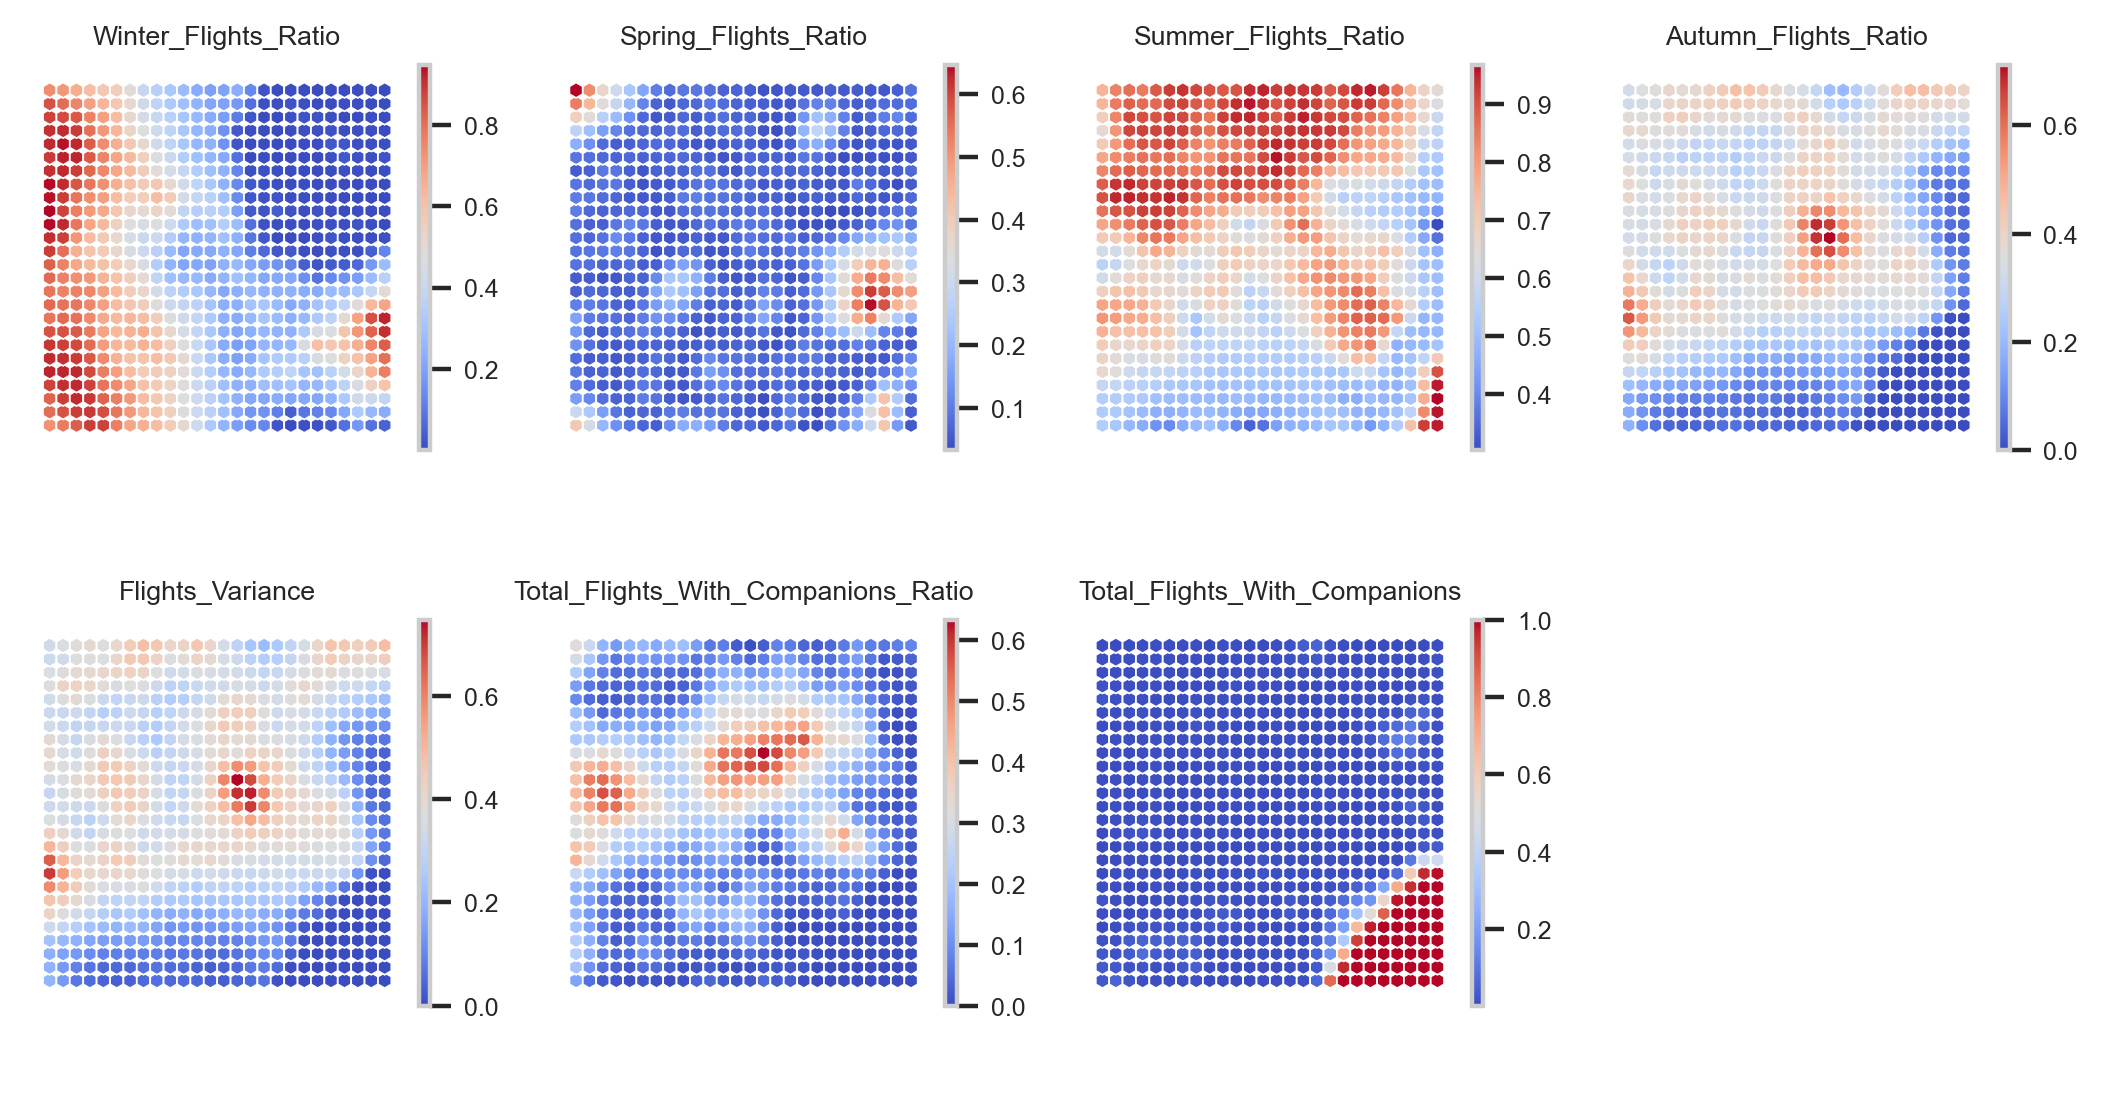

In [107]:
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5.5), dpi=128, constrained_layout=False)
fig.subplots_adjust(hspace=0.05, wspace=0.3)

axes = axes.flatten()

for i, feat in enumerate(feats_PP):
    ax = axes[i]
    matrix_vals = weights_som[:, :, i]

    norm = mpl_colors.Normalize(vmin=matrix_vals.min(), vmax=matrix_vals.max())

    plot_hexagons_ax(
        som=sm,
        ax=ax,
        matrix_vals=matrix_vals,
        colornorm=norm,
        label=feat,
        cmap=cm.coolwarm,
        annot=False
    )

# turn off any leftover axes if feats_PP < nrows*ncols
for ax in axes[len(feats_PP):]:
    ax.axis("off")

plt.show()

o que tinha antes:

In [ ]:
som_data = cluster_dataset.values 

sm = MiniSom(
    x=26, 
    y=26, 
    input_len=som_data.shape[1],
    sigma=2.0,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)
sm.train_random(som_data, num_iteration=17048*5, verbose=True)

 [ 85240 / 85240 ] 100% - 0:00:00 left 
 quantization error: 0.2325611624096133


In [ ]:
# Calcular o Erro Topográfico
te = sm.topographic_error(som_data)
print(f"Topographic Error: {te}")

Topographic Error: 0.1928928046989721


Perspective 1 (df_VE)
 [ 85240 / 85240 ] 100% - 0:00:00 left 
 quantization error: 0.10728163653406549

 QE: 0.1073 | TE: N/A (Não suportado em Hexagonal)


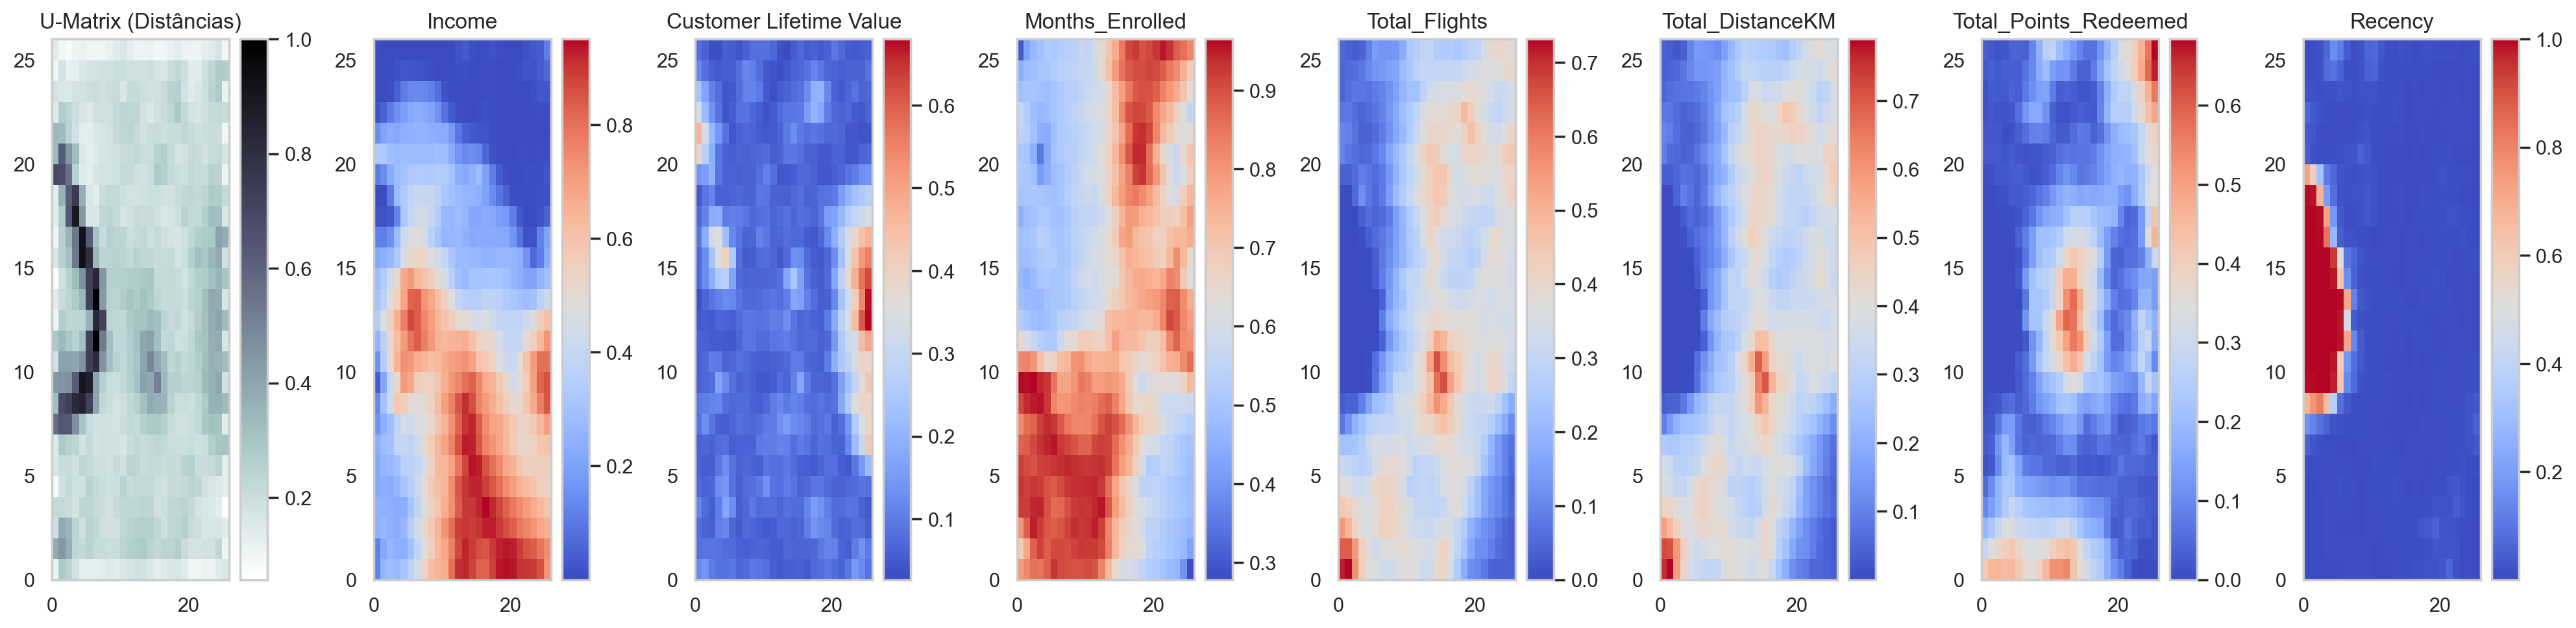

In [ ]:
import matplotlib.pyplot as plt
from minisom import MiniSom
import numpy as np

# Perspective 1 using SOM 
print("Perspective 1 (df_VE)")

som_data_p1 = df_VE.values
n_features_p1 = som_data_p1.shape[1]

# --- ADAPTAÇÃO AQUI ---
sm_p1 = MiniSom(
    x=26, 
    y=26, 
    input_len=n_features_p1, 
    sigma=2.0,                        # Mantive o teu valor (ajusta se quiseres igual ao exemplo: 1.5)
    learning_rate=0.5, 
    neighborhood_function='gaussian', # Adicionado do exemplo RGB
    topology='hexagonal',             # Adicionado do exemplo RGB
    random_seed=42
)

# INITIALIZATION
sm_p1.random_weights_init(som_data_p1)

# TRAINING
sm_p1.train_random(som_data_p1, num_iteration=17048*5, verbose=True)

# Quantization Error
qe_p1 = sm_p1.quantization_error(som_data_p1)

# --- CORREÇÃO DO ERRO ---
# O Topographic Error NÃO funciona com topology='hexagonal' no MiniSom padrão.
# A linha abaixo foi comentada para o código não falhar:
# te_p1 = sm_p1.topographic_error(som_data_p1) 

print(f"\n QE: {qe_p1:.4f} | TE: N/A (Não suportado em Hexagonal)")

# --- PLOTTING (Versão Pcolor/Quadrada) ---
# Nota: Como estás a usar topologia Hexagonal, este gráfico vai aparecer "torto" 
# (os vizinhos não correspondem visualmente à realidade matemática).
# Para veres os hexágonos reais, terias de usar a função da professora.

plt.figure(figsize=(20, 5))

# Plot U-Matrix
plt.subplot(1, n_features_p1 + 1, 1)
plt.title('U-Matrix (Distâncias)')
plt.pcolor(sm_p1.distance_map().T, cmap='bone_r')
plt.colorbar()

# Plot Component Planes
for i, col_name in enumerate(df_VE.columns):
    plt.subplot(1, n_features_p1 + 1, i + 2)
    plt.title(f'{col_name}')
    plt.pcolor(sm_p1.get_weights()[:, :, i].T, cmap='coolwarm')
    plt.colorbar()

plt.tight_layout()
plt.show()

A calcular o nº ideal de clusters para a Perspetiva 1...


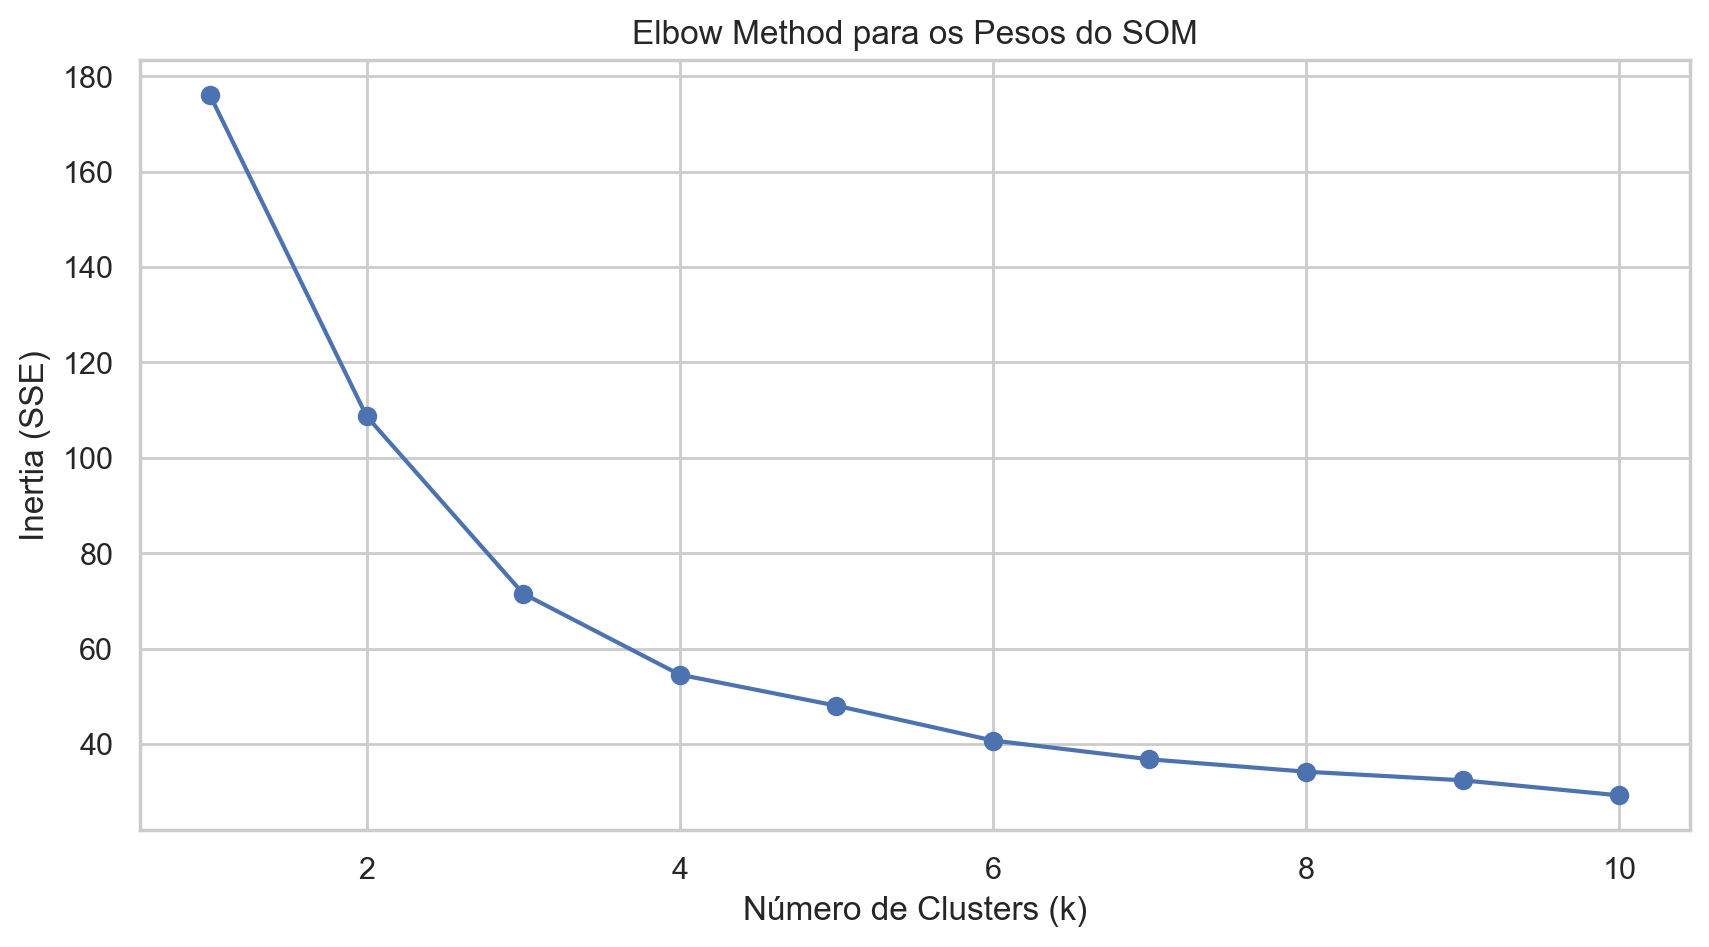

A calcular o nº ideal de clusters para a Perspetiva 2...


NameError: name 'sm_p2' is not defined

In [ ]:
from sklearn.cluster import KMeans

def plot_som_elbow(som_model, max_k=10):
    # 1. Extrair os pesos (o esqueleto do mapa)
    weights = som_model.get_weights().reshape(-1, som_model._input_len)
    
    sse = []
    # 2. Testar de 1 a 10 clusters
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(weights)
        sse.append(kmeans.inertia_) # Soma dos erros quadrados
    
    # 3. Plotar o gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, max_k + 1), sse, marker='o')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inertia (SSE)')
    plt.title('Elbow Method para os Pesos do SOM')
    plt.grid(True)
    plt.show()

# --- Corre isto para ver o gráfico ---
print("A calcular o nº ideal de clusters para a Perspetiva 1...")
plot_som_elbow(sm_p1) # sm_p1 é o modelo da tua perspetiva 1

print("A calcular o nº ideal de clusters para a Perspetiva 2...")
plot_som_elbow(sm_p2) # sm_p2 é o modelo da tua perspetiva 2

testar com 4 e com 5 

Perspective 2 (df_PP)
 [ 85240 / 85240 ] 100% - 0:00:00 left 
 quantization error: 0.08362153295367976

 QE: 0.0836 | TE: 0.1633


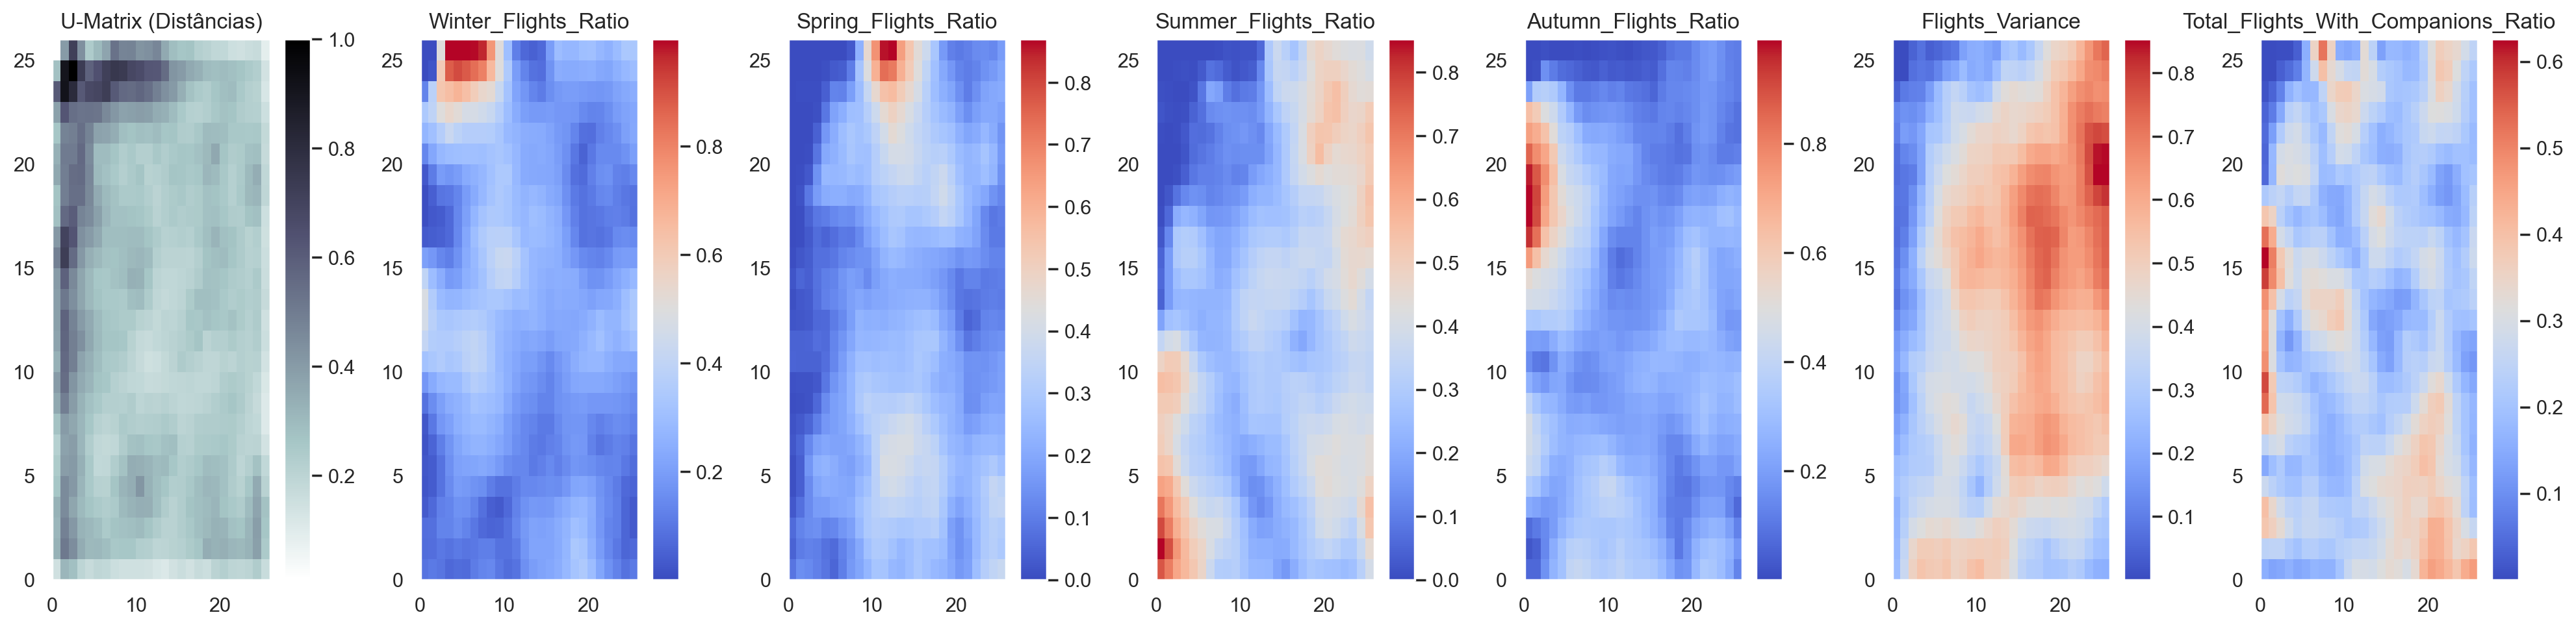

In [ ]:
# Perspective 2 using SOM
print("Perspective 2 (df_PP)")

som_data_p2 = df_PP.values
n_features_p2 = som_data_p2.shape[1]

sm_p2 = MiniSom(
    x=26, 
    y=26, 
    input_len=n_features_p2, 
    sigma=2.0, 
    learning_rate=0.5, 
    random_seed=42
)

# INITIALIZATION
sm_p2.random_weights_init(som_data_p2)

# TRAINING
sm_p2.train_random(som_data_p2, num_iteration=17048*5, verbose=True)

# Quantization and Topographic Errors
qe_p2 = sm_p2.quantization_error(som_data_p2)
te_p2 = sm_p2.topographic_error(som_data_p2)
print(f"\n QE: {qe_p2:.4f} | TE: {te_p2:.4f}")

plt.figure(figsize=(20, 5))
plt.subplot(1, n_features_p2 + 1, 1)
plt.title('U-Matrix (Distâncias)')
plt.pcolor(sm_p2.distance_map().T, cmap='bone_r')
plt.colorbar()

for i, col_name in enumerate(df_PP.columns):
    plt.subplot(1, n_features_p2 + 1, i + 2)
    plt.title(f'{col_name}')
    plt.pcolor(sm_p2.get_weights()[:, :, i].T, cmap='coolwarm')
    plt.colorbar()

plt.tight_layout()
plt.show()